In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

FILE_PATH = r"D:\document\Brahmaputra-FloodCast\data\final\darrang_water_level_final.csv"

df = pd.read_csv(FILE_PATH)

print("Dataset loaded successfully")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully
Shape: (11124, 24)


,Data Acquisition Time,_id,SlNo,Station,Agency,State LGD Code,State,District LGD Code,District,Tehsil,...,Tributary,Subtributary,SubSubtributary,Local River,Latitude,Longitude,Is_DischargeDataAvailable,RL_of_zeroGauge,MeanSeaLevel,River Water Level Telemetry Hourly (meter)
0,2022-01-01 20:00:00,16499,16499,NH15 Crossing Fakirpara Tangni,Assam,18,Assam,283,DARRANG,-,...,-,-,-,-,26.508333,92.116389,No,0,0,1.275
1,2022-01-03 00:00:00,16534,16534,NH15 Crossing Fakirpara Tangni,Assam,18,Assam,283,DARRANG,-,...,-,-,-,-,26.508333,92.116389,No,0,0,0.159
2,2022-01-03 01:00:00,16535,16535,NH15 Crossing Fakirpara Tangni,Assam,18,Assam,283,DARRANG,-,...,-,-,-,-,26.508333,92.116389,No,0,0,0.158
3,2022-01-03 02:00:00,16536,16536,NH15 Crossing Fakirpara Tangni,Assam,18,Assam,283,DARRANG,-,...,-,-,-,-,26.508333,92.116389,No,0,0,0.160
4,2022-01-03 03:00:00,16537,16537,NH15 Crossing Fakirpara Tangni,Assam,18,Assam,283,DARRANG,-,...,-,-,-,-,26.508333,92.116389,No,0,0,0.161


In [2]:
print("=" * 70)
print("DATASET INFO")
print("=" * 70)

print("\nShape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

DATASET INFO

Shape:
(11124, 24)

Columns:
['Data Acquisition Time', '_id', 'SlNo', 'Station', 'Agency', 'State LGD Code', 'State', 'District LGD Code', 'District', 'Tehsil', 'Block', 'Village', 'River', 'Basin', 'Tributary', 'Subtributary', 'SubSubtributary', 'Local River', 'Latitude', 'Longitude', 'Is_DischargeDataAvailable', 'RL_of_zeroGauge', 'MeanSeaLevel', 'River Water Level Telemetry Hourly (meter)']

Data Types:
Data Acquisition Time                             str
_id                                             int64
SlNo                                            int64
Station                                           str
Agency                                            str
State LGD Code                                  int64
State                                             str
District LGD Code                               int64
District                                          str
Tehsil                                            str
Block                               

In [3]:
print("=" * 70)
print("STATISTICAL SUMMARY")
print("=" * 70)

print(df.describe())

STATISTICAL SUMMARY
                _id          SlNo  State LGD Code  District LGD Code  \
count  11124.000000  11124.000000         11124.0            11124.0   
mean   32778.131787  32778.131787            18.0              283.0   
std    13439.617111  13439.617111             0.0                0.0   
min        1.000000      1.000000            18.0              283.0   
25%    23384.500000  23384.500000            18.0              283.0   
50%    33446.000000  33446.000000            18.0              283.0   
75%    43884.250000  43884.250000            18.0              283.0   
max    52872.000000  52872.000000            18.0              283.0   

           Latitude     Longitude  RL_of_zeroGauge  MeanSeaLevel  \
count  11124.000000  1.112400e+04          11124.0       11124.0   
mean      26.508333  9.211639e+01              0.0           0.0   
std        0.000000  1.421149e-14              0.0           0.0   
min       26.508333  9.211639e+01              0.0         

In [4]:
water_col = "River Water Level Telemetry Hourly (meter)"

print("=" * 70)
print("WATER LEVEL ANALYSIS")
print("=" * 70)

print("\nMissing Water Level Values:")
print(df[water_col].isnull().sum())

print("\nZero Values:")
print((df[water_col] == 0).sum())

print("\nValues Greater Than 50 m:")
print((df[water_col] > 50).sum())

print("\nValues Greater Than 100 m:")
print((df[water_col] > 100).sum())

print("\nTop 10 Highest Water Levels:")
print(df[[water_col]].sort_values(by=water_col, ascending=False).head(10))

WATER LEVEL ANALYSIS

Missing Water Level Values:
45

Zero Values:
0

Values Greater Than 50 m:
1760

Values Greater Than 100 m:
4

Top 10 Highest Water Levels:
      River Water Level Telemetry Hourly (meter)
3476                                     641.231
916                                      624.669
5281                                     608.700
3956                                     529.533
9182                                      62.636
9183                                      62.593
9181                                      62.588
9179                                      62.559
9180                                      62.547
9178                                      62.524


In [6]:
print(df.columns.tolist())

['Data Acquisition Time', '_id', 'SlNo', 'Station', 'Agency', 'State LGD Code', 'State', 'District LGD Code', 'District', 'Tehsil', 'Block', 'Village', 'River', 'Basin', 'Tributary', 'Subtributary', 'SubSubtributary', 'Local River', 'Latitude', 'Longitude', 'Is_DischargeDataAvailable', 'RL_of_zeroGauge', 'MeanSeaLevel', 'River Water Level Telemetry Hourly (meter)']


In [7]:
print("=" * 70)
print("EXTREME WATER LEVELS WITH DATE/TIME")
print("=" * 70)

print(
    df[[water_col, "Data Acquisition Time"]]
    .sort_values(by=water_col, ascending=False)
    .head(20)
)

EXTREME WATER LEVELS WITH DATE/TIME
      River Water Level Telemetry Hourly (meter) Data Acquisition Time
3476                                     641.231   2023-06-09 22:00:00
916                                      624.669   2022-06-09 21:00:00
5281                                     608.700   2024-01-09 15:00:00
3956                                     529.533   2023-08-08 14:00:00
9182                                      62.636   2025-05-06 11:00:00
9183                                      62.593   2025-05-06 12:00:00
9181                                      62.588   2025-05-06 10:00:00
9179                                      62.559   2025-05-06 08:00:00
9180                                      62.547   2025-05-06 09:00:00
9178                                      62.524   2025-05-06 07:00:00
9184                                      62.497   2025-05-06 13:00:00
9177                                      62.447   2025-05-06 06:00:00
9185                                     

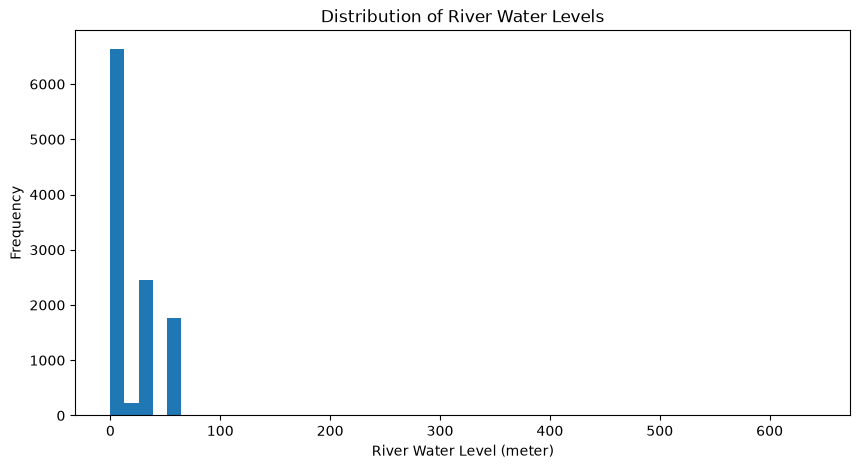

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(df[water_col].dropna(), bins=50)

plt.xlabel("River Water Level (meter)")
plt.ylabel("Frequency")
plt.title("Distribution of River Water Levels")

plt.show()

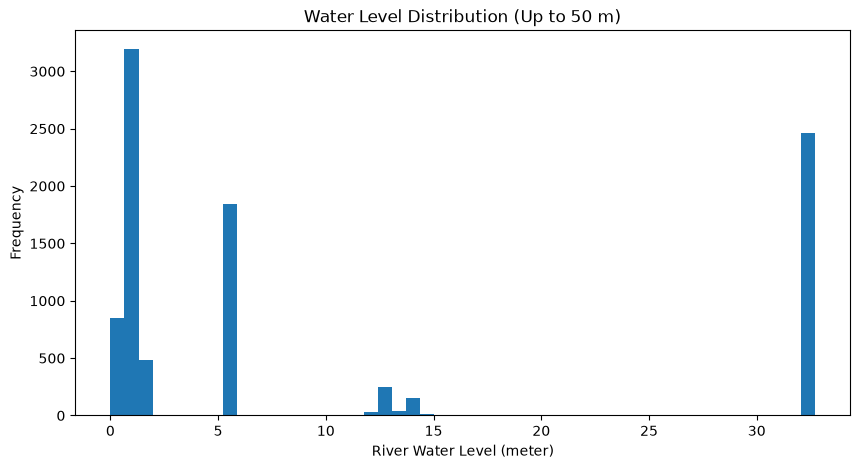

In [6]:
import matplotlib.pyplot as plt

water_col = "River Water Level Telemetry Hourly (meter)"

plt.figure(figsize=(10, 5))

plt.hist(
    df.loc[df[water_col] <= 50, water_col].dropna(),
    bins=50
)

plt.xlabel("River Water Level (meter)")
plt.ylabel("Frequency")
plt.title("Water Level Distribution (Up to 50 m)")

plt.show()

In [7]:
print("=" * 70)
print("WATER LEVEL RANGE ANALYSIS")
print("=" * 70)

print("\n0–5 m:")
print((df[water_col] <= 5).sum())

print("\n5–10 m:")
print(((df[water_col] > 5) & (df[water_col] <= 10)).sum())

print("\n10–20 m:")
print(((df[water_col] > 10) & (df[water_col] <= 20)).sum())

print("\n20–30 m:")
print(((df[water_col] > 20) & (df[water_col] <= 30)).sum())

print("\n30–40 m:")
print(((df[water_col] > 30) & (df[water_col] <= 40)).sum())

print("\n40–50 m:")
print(((df[water_col] > 40) & (df[water_col] <= 50)).sum())

print("\nAbove 50 m:")
print((df[water_col] > 50).sum())

WATER LEVEL RANGE ANALYSIS

0–5 m:
4530

5–10 m:
1844

10–20 m:
483

20–30 m:
0

30–40 m:
2462

40–50 m:
0

Above 50 m:
1760


In [8]:
print("=" * 70)
print("BOUNDARY VALUE ANALYSIS")
print("=" * 70)

print("\nValues around 20 m:")
print(
    df.loc[
        (df[water_col] >= 15) & (df[water_col] <= 35),
        [water_col, "Data Acquisition Time"]
    ].sort_values(by=water_col).head(30)
)

print("\nValues around 40–50 m:")
print(
    df.loc[
        (df[water_col] >= 35) & (df[water_col] <= 55),
        [water_col, "Data Acquisition Time"]
    ].sort_values(by=water_col).head(30)
)

BOUNDARY VALUE ANALYSIS

Values around 20 m:
       River Water Level Telemetry Hourly (meter) Data Acquisition Time
6558                                       32.636   2024-06-08 05:00:00
5227                                       32.700   2024-01-07 06:00:00
10186                                      32.700   2025-11-02 23:00:00
10329                                      32.700   2025-12-01 00:00:00
10330                                      32.700   2025-12-01 01:00:00
10331                                      32.700   2025-12-01 02:00:00
10332                                      32.700   2025-12-01 03:00:00
10333                                      32.700   2025-12-01 09:00:00
10334                                      32.700   2025-12-01 10:00:00
10335                                      32.700   2025-12-02 00:00:00
10336                                      32.700   2025-12-02 01:00:00
10337                                      32.700   2025-12-02 02:00:00
10338              

In [9]:
print("=" * 70)
print("MOST FREQUENT WATER LEVEL VALUES")
print("=" * 70)

print("\nTop 20 Most Frequent Values:")

print(
    df[water_col]
    .value_counts()
    .head(20)
)

print("\nExact 32.700 Count:")

print(
    (df[water_col] == 32.700).sum()
)

MOST FREQUENT WATER LEVEL VALUES

Top 20 Most Frequent Values:
River Water Level Telemetry Hourly (meter)
32.700    2460
5.763     1842
12.600      86
12.700      81
14.100      44
1.289       43
1.290       38
1.291       35
12.500      35
1.283       34
1.286       34
1.258       34
14.200      33
1.252       32
1.260       32
14.300      32
1.284       29
1.294       28
1.287       28
1.256       27
Name: count, dtype: int64

Exact 32.700 Count:
2460


In [10]:
print("=" * 70)
print("FIXED VALUE TIME PATTERN")
print("=" * 70)

print("\n32.700 — First 10 occurrences:")

print(
    df.loc[
        df[water_col] == 32.700,
        ["Data Acquisition Time", water_col]
    ].head(10)
)

print("\n32.700 — Last 10 occurrences:")

print(
    df.loc[
        df[water_col] == 32.700,
        ["Data Acquisition Time", water_col]
    ].tail(10)
)

print("\n5.763 — First 10 occurrences:")

print(
    df.loc[
        df[water_col] == 5.763,
        ["Data Acquisition Time", water_col]
    ].head(10)
)

print("\n5.763 — Last 10 occurrences:")

print(
    df.loc[
        df[water_col] == 5.763,
        ["Data Acquisition Time", water_col]
    ].tail(10)
)

FIXED VALUE TIME PATTERN

32.700 — First 10 occurrences:
     Data Acquisition Time  River Water Level Telemetry Hourly (meter)
5212   2024-01-06 15:00:00                                        32.7
5213   2024-01-06 15:45:00                                        32.7
5214   2024-01-06 16:00:00                                        32.7
5215   2024-01-06 17:00:00                                        32.7
5216   2024-01-06 18:00:00                                        32.7
5217   2024-01-06 19:00:00                                        32.7
5218   2024-01-06 20:00:00                                        32.7
5219   2024-01-06 21:00:00                                        32.7
5220   2024-01-06 22:00:00                                        32.7
5221   2024-01-06 23:00:00                                        32.7

32.700 — Last 10 occurrences:
      Data Acquisition Time  River Water Level Telemetry Hourly (meter)
10347   2025-12-02 12:00:00                                

In [11]:
print("=" * 70)
print("CONSECUTIVE REPEATED WATER LEVELS")
print("=" * 70)

temp = df[
    ["Data Acquisition Time", water_col]
].dropna().sort_values("Data Acquisition Time").copy()

temp["same_as_previous"] = (
    temp[water_col] == temp[water_col].shift()
)

groups = (
    temp["same_as_previous"] != temp["same_as_previous"].shift()
).cumsum()

repeated_runs = (
    temp.groupby(groups)
    .agg(
        Water_Level=(water_col, "first"),
        Start_Time=("Data Acquisition Time", "first"),
        End_Time=("Data Acquisition Time", "last"),
        Number_of_Readings=(water_col, "size")
    )
)

print(
    repeated_runs
    .sort_values("Number_of_Readings", ascending=False)
    .head(20)
)

CONSECUTIVE REPEATED WATER LEVELS
                  Water_Level           Start_Time             End_Time  \
same_as_previous                                                          
1038                   32.700  2024-12-06 01:00:00  2025-01-03 23:00:00   
962                    32.700  2024-09-06 01:00:00  2024-09-12 23:00:00   
990                    32.700  2024-10-06 01:00:00  2024-10-12 23:00:00   
932                    32.700  2024-08-06 01:00:00  2024-08-12 23:00:00   
900                    32.700  2024-07-06 01:00:00  2024-07-12 23:00:00   
1016                   32.700  2024-11-06 01:00:00  2024-11-12 23:00:00   
806                    32.700  2024-03-06 01:00:00  2024-03-12 23:00:00   
778                    32.700  2024-02-06 01:00:00  2024-02-12 23:00:00   
850                    32.700  2024-05-06 01:00:00  2024-05-12 23:00:00   
824                    32.700  2024-04-06 01:00:00  2024-04-12 23:00:00   
3                       0.253  2022-01-03 18:00:00  2022-01-11 20:

In [12]:
print("=" * 70)
print("DATE/TIME VERIFICATION")
print("=" * 70)

print("\nData Type:")
print(df["Data Acquisition Time"].dtype)

print("\nFirst 10 timestamps:")
print(df["Data Acquisition Time"].head(10))

print("\nLast 10 timestamps:")
print(df["Data Acquisition Time"].tail(10))

print("\nDuplicate timestamps:")
print(df["Data Acquisition Time"].duplicated().sum())

print("\nTotal rows:")
print(len(df))

DATE/TIME VERIFICATION

Data Type:
str

First 10 timestamps:
0    2022-01-01 20:00:00
1    2022-01-03 00:00:00
2    2022-01-03 01:00:00
3    2022-01-03 02:00:00
4    2022-01-03 03:00:00
5    2022-01-03 04:00:00
6    2022-01-03 05:00:00
7    2022-01-03 06:00:00
8    2022-01-03 07:00:00
9    2022-01-03 08:00:00
Name: Data Acquisition Time, dtype: str

Last 10 timestamps:
11114    2026-12-05 12:00:00
11115    2026-12-05 13:00:00
11116    2026-12-05 14:00:00
11117    2026-12-05 15:00:00
11118    2026-12-05 16:00:00
11119    2026-12-05 17:00:00
11120    2026-12-05 18:00:00
11121    2026-12-05 19:00:00
11122    2026-12-05 20:00:00
11123    2026-12-05 22:00:00
Name: Data Acquisition Time, dtype: str

Duplicate timestamps:
0

Total rows:
11124


In [13]:
df["Data Acquisition Time"] = pd.to_datetime(
    df["Data Acquisition Time"],
    errors="coerce"
)

print("=" * 70)
print("DATETIME CONVERSION")
print("=" * 70)

print("\nData Type:")
print(df["Data Acquisition Time"].dtype)

print("\nMissing/Invalid Timestamps:")
print(df["Data Acquisition Time"].isnull().sum())

DATETIME CONVERSION

Data Type:
datetime64[us]

Missing/Invalid Timestamps:
0


In [14]:
print("=" * 70)
print("CHRONOLOGY CHECK")
print("=" * 70)

print("\nAlready Sorted:")
print(df["Data Acquisition Time"].is_monotonic_increasing)

print("\nEarliest Timestamp:")
print(df["Data Acquisition Time"].min())

print("\nLatest Timestamp:")
print(df["Data Acquisition Time"].max())

CHRONOLOGY CHECK

Already Sorted:
True

Earliest Timestamp:
2022-01-01 20:00:00

Latest Timestamp:
2026-12-05 22:00:00


In [15]:
print("=" * 70)
print("TIME GAP ANALYSIS")
print("=" * 70)

time_diff = df["Data Acquisition Time"].diff()

print("\nMost Common Time Gaps:")
print(time_diff.value_counts().head(10))

print("\nGaps Greater Than 1 Hour:")
print((time_diff > pd.Timedelta(hours=1)).sum())

print("\nLargest Time Gap:")
print(time_diff.max())

TIME GAP ANALYSIS

Most Common Time Gaps:
Data Acquisition Time
0 days 01:00:00     10614
0 days 02:00:00       291
0 days 03:00:00        67
0 days 04:00:00        23
1 days 01:00:00        18
0 days 05:00:00        14
19 days 01:00:00       14
0 days 07:00:00        10
18 days 01:00:00        8
21 days 01:00:00        6
Name: count, dtype: int64

Gaps Greater Than 1 Hour:
507

Largest Time Gap:
67 days 01:00:00


In [16]:
print("=" * 70)
print("LARGEST TIME GAPS")
print("=" * 70)

gap_df = pd.DataFrame({
    "Previous_Time": df["Data Acquisition Time"].shift(1),
    "Current_Time": df["Data Acquisition Time"],
    "Gap": time_diff
})

print(
    gap_df
    .sort_values(by="Gap", ascending=False)
    .head(20)
)

LARGEST TIME GAPS
            Previous_Time        Current_Time              Gap
10569 2026-03-06 23:00:00 2026-05-13 00:00:00 67 days 01:00:00
11002 2026-05-31 23:00:00 2026-07-05 20:00:00 34 days 21:00:00
11078 2026-10-05 23:00:00 2026-11-05 00:00:00 30 days 01:00:00
11030 2026-08-05 23:00:00 2026-09-05 00:00:00 30 days 01:00:00
11006 2026-07-05 23:00:00 2026-08-05 00:00:00 30 days 01:00:00
10522 2026-01-06 23:00:00 2026-02-06 00:00:00 30 days 01:00:00
11102 2026-11-05 23:00:00 2026-12-05 00:00:00 29 days 01:00:00
11054 2026-09-05 23:00:00 2026-10-05 00:00:00 29 days 01:00:00
10498 2025-12-09 11:00:00 2026-01-06 00:00:00 27 days 13:00:00
10545 2026-02-06 23:00:00 2026-03-06 00:00:00 27 days 01:00:00
9243  2025-05-08 23:00:00 2025-06-01 00:00:00 23 days 01:00:00
10145 2025-10-08 23:00:00 2025-11-01 00:00:00 23 days 01:00:00
9791  2025-08-08 23:00:00 2025-09-01 00:00:00 23 days 01:00:00
9607  2025-07-08 23:00:00 2025-08-01 00:00:00 23 days 01:00:00
8514  2025-01-08 23:00:00 2025-02-01 

In [17]:
print("=" * 70)
print("MONTHLY DATA AVAILABILITY")
print("=" * 70)

monthly_counts = (
    df.groupby(
        df["Data Acquisition Time"].dt.to_period("M")
    )
    .size()
)

print(monthly_counts)

MONTHLY DATA AVAILABILITY
Data Acquisition Time
2022-01    176
2022-02    160
2022-03    151
2022-04    159
2022-05    155
2022-06    190
2022-07    193
2022-08    177
2022-09    171
2022-10    154
2022-11    172
2022-12    163
2023-01    258
2023-02    259
2023-03    249
2023-04    256
2023-05    251
2023-06    255
2023-07    259
2023-08    254
2023-09    251
2023-10    254
2023-11    260
2023-12    264
2024-01    266
2024-02    266
2024-03    260
2024-04    254
2024-05    253
2024-06    283
2024-07    274
2024-08    276
2024-09    286
2024-10    276
2024-11    265
2024-12    279
2025-01    185
2025-02    186
2025-03    182
2025-04    175
2025-05    186
2025-06    180
2025-07    184
2025-08    184
2025-09    174
2025-10    180
2025-11    184
2025-12    169
2026-01     24
2026-02     23
2026-03     24
2026-05    433
2026-07      4
2026-08     24
2026-09     24
2026-10     24
2026-11     24
2026-12     22
Freq: M, dtype: int64


In [18]:
print("=" * 70)
print("MONTHLY DATA COVERAGE")
print("=" * 70)

monthly_data = (
    df.groupby(
        df["Data Acquisition Time"].dt.to_period("M")
    )
    .size()
    .reset_index(name="Actual_Readings")
)

monthly_data["Expected_Readings"] = (
    monthly_data["Data Acquisition Time"]
    .dt.days_in_month * 24
)

monthly_data["Coverage_Percentage"] = (
    monthly_data["Actual_Readings"]
    / monthly_data["Expected_Readings"]
    * 100
)

print(monthly_data.to_string(index=False))

MONTHLY DATA COVERAGE
Data Acquisition Time  Actual_Readings  Expected_Readings  Coverage_Percentage
              2022-01              176                744            23.655914
              2022-02              160                672            23.809524
              2022-03              151                744            20.295699
              2022-04              159                720            22.083333
              2022-05              155                744            20.833333
              2022-06              190                720            26.388889
              2022-07              193                744            25.940860
              2022-08              177                744            23.790323
              2022-09              171                720            23.750000
              2022-10              154                744            20.698925
              2022-11              172                720            23.888889
              2022-12         

In [19]:
print("=" * 70)
print("MONTHLY WATER LEVEL STATISTICS")
print("=" * 70)

monthly_water = (
    df.groupby(
        df["Data Acquisition Time"].dt.to_period("M")
    )[water_col]
    .agg(["count", "mean", "median", "min", "max"])
)

print(monthly_water)

MONTHLY WATER LEVEL STATISTICS
                       count       mean     median     min      max
Data Acquisition Time                                              
2022-01                  176   0.689928   0.535500   0.158    1.305
2022-02                  160   0.797106   0.649000   0.194    1.300
2022-03                  151   0.817797   0.589026   0.216    1.301
2022-04                  159   0.853293   0.711250   0.244    1.302
2022-05                  155   0.922564   0.972545   0.074    1.375
2022-06                  190   4.116119   0.781300   0.223  624.669
2022-07                  192   0.846452   0.816187   0.213    1.296
2022-08                  167   0.803745   0.807000   0.001    1.378
2022-09                  158   0.849903   0.852952   0.001    1.313
2022-10                  141   0.910054   1.234000   0.252    1.378
2022-11                  168   0.777968   0.495708   0.001    1.376
2022-12                  159   0.815876   0.743667   0.256    1.403
2023-01          

In [20]:
print("=" * 70)
print("YEAR-WISE WATER LEVEL STATISTICS")
print("=" * 70)

yearly_water = (
    df.groupby(
        df["Data Acquisition Time"].dt.year
    )[water_col]
    .agg(["count", "mean", "median", "min", "max"])
)

print(yearly_water)

YEAR-WISE WATER LEVEL STATISTICS
                       count       mean  median     min      max
Data Acquisition Time                                           
2022                    1976   1.140159   0.774   0.001  624.669
2023                    3070   3.819134   1.473   0.943  641.231
2024                    3238  20.368279  32.700   0.840  608.700
2025                    2169  42.982795  60.243  11.400   62.636
2026                     626  60.997947  60.982  60.882   61.317


In [21]:
print("=" * 70)
print("YEAR-WISE MOST FREQUENT WATER LEVEL VALUES")
print("=" * 70)

for year in sorted(df["Data Acquisition Time"].dt.year.unique()):
    
    print(f"\n{year}:")
    
    yearly_counts = (
        df.loc[
            df["Data Acquisition Time"].dt.year == year,
            water_col
        ]
        .value_counts()
        .head(5)
    )
    
    print(yearly_counts)
    

YEAR-WISE MOST FREQUENT WATER LEVEL VALUES

2022:
River Water Level Telemetry Hourly (meter)
1.290    23
1.286    23
1.287    20
1.284    20
1.289    19
Name: count, dtype: int64

2023:
River Water Level Telemetry Hourly (meter)
5.763    1481
1.258      27
1.252      24
1.260      24
1.289      24
Name: count, dtype: int64

2024:
River Water Level Telemetry Hourly (meter)
32.700    1904
5.763      361
0.898       14
0.961       13
0.964       13
Name: count, dtype: int64

2025:
River Water Level Telemetry Hourly (meter)
32.7    556
12.6     86
12.7     81
14.1     44
12.5     35
Name: count, dtype: int64

2026:
River Water Level Telemetry Hourly (meter)
60.935    11
60.942    10
60.934     8
60.900     8
61.060     8
Name: count, dtype: int64


In [22]:
print("=" * 70)
print("EXTREME VALUE CONTEXT")
print("=" * 70)

extreme_indices = (
    df[water_col]
    .nlargest(4)
    .index
)

for idx in extreme_indices:
    
    print("\n" + "-" * 70)
    print("Extreme Value:", df.loc[idx, water_col])
    print("Time:", df.loc[idx, "Data Acquisition Time"])
    print("-" * 70)
    
    print(
        df.loc[
            max(0, idx - 3): idx + 3,
            ["Data Acquisition Time", water_col]
        ]
    )

EXTREME VALUE CONTEXT

----------------------------------------------------------------------
Extreme Value: 641.231
Time: 2023-06-09 22:00:00
----------------------------------------------------------------------
     Data Acquisition Time  River Water Level Telemetry Hourly (meter)
3473   2023-06-09 19:00:00                                       1.237
3474   2023-06-09 20:00:00                                       1.235
3475   2023-06-09 21:00:00                                       1.233
3476   2023-06-09 22:00:00                                     641.231
3477   2023-06-09 23:00:00                                       1.229
3478   2023-06-10 00:00:00                                       5.763
3479   2023-06-10 01:00:00                                       5.763

----------------------------------------------------------------------
Extreme Value: 624.669
Time: 2022-06-09 21:00:00
----------------------------------------------------------------------
    Data Acquisition Time 

In [23]:
print("=" * 70)
print("ALL VALUES GREATER THAN 100 m")
print("=" * 70)

extreme_100 = (
    df.loc[
        df[water_col] > 100,
        ["Data Acquisition Time", water_col]
    ]
    .sort_values(by=water_col, ascending=False)
)

print(extreme_100.to_string(index=False))

ALL VALUES GREATER THAN 100 m
Data Acquisition Time  River Water Level Telemetry Hourly (meter)
  2023-06-09 22:00:00                                     641.231
  2022-06-09 21:00:00                                     624.669
  2024-01-09 15:00:00                                     608.700
  2023-08-08 14:00:00                                     529.533


In [24]:
print("=" * 70)
print("MISSING WATER LEVEL ANALYSIS")
print("=" * 70)

missing_water = df[df[water_col].isna()]

print("\nTotal Missing Water Levels:")
print(len(missing_water))

print("\nMissing Water Level Timestamps:")
print(
    missing_water[
        ["Data Acquisition Time"]
    ].to_string(index=False)
)

MISSING WATER LEVEL ANALYSIS

Total Missing Water Levels:
45

Missing Water Level Timestamps:
Data Acquisition Time
  2022-07-05 08:00:00
  2022-08-04 11:00:00
  2022-08-04 12:00:00
  2022-08-04 13:00:00
  2022-08-04 15:00:00
  2022-08-04 16:00:00
  2022-08-04 17:00:00
  2022-08-04 19:00:00
  2022-08-04 20:00:00
  2022-08-04 21:00:00
  2022-08-04 22:00:00
  2022-09-04 09:00:00
  2022-09-04 10:00:00
  2022-09-04 12:00:00
  2022-09-04 13:00:00
  2022-09-04 14:00:00
  2022-09-04 15:00:00
  2022-09-04 16:00:00
  2022-09-04 17:00:00
  2022-09-04 18:00:00
  2022-09-04 20:00:00
  2022-09-04 21:00:00
  2022-09-04 22:00:00
  2022-09-04 23:00:00
  2022-10-04 10:00:00
  2022-10-05 00:00:00
  2022-10-05 02:00:00
  2022-10-05 03:00:00
  2022-10-05 04:00:00
  2022-10-05 05:00:00
  2022-10-05 09:00:00
  2022-10-05 10:00:00
  2022-10-05 11:00:00
  2022-10-05 13:00:00
  2022-10-05 15:00:00
  2022-10-05 17:00:00
  2022-10-05 18:00:00
  2022-11-04 14:00:00
  2022-11-04 15:00:00
  2022-11-04 16:00:00
  20

In [25]:
print("=" * 70)
print("MISSING VALUE CONTEXT")
print("=" * 70)

missing_idx = df.index[df[water_col].isna()]

for idx in missing_idx[:15]:
    
    print("\n" + "-" * 70)
    
    print("Missing Time:")
    print(df.loc[idx, "Data Acquisition Time"])
    
    print("\nPrevious Reading:")
    if idx > 0:
        print(
            df.loc[
                idx - 1,
                ["Data Acquisition Time", water_col]
            ]
        )
    
    print("\nNext Reading:")
    if idx < len(df) - 1:
        print(
            df.loc[
                idx + 1,
                ["Data Acquisition Time", water_col]
            ]
        )

MISSING VALUE CONTEXT

----------------------------------------------------------------------
Missing Time:
2022-07-05 08:00:00

Previous Reading:
Data Acquisition Time                         2022-07-05 07:00:00
River Water Level Telemetry Hourly (meter)               0.790625
Name: 1040, dtype: object

Next Reading:
Data Acquisition Time                         2022-07-05 09:00:00
River Water Level Telemetry Hourly (meter)               0.795375
Name: 1042, dtype: object

----------------------------------------------------------------------
Missing Time:
2022-08-04 11:00:00

Previous Reading:
Data Acquisition Time                         2022-08-04 10:00:00
River Water Level Telemetry Hourly (meter)               0.227295
Name: 1208, dtype: object

Next Reading:
Data Acquisition Time                         2022-08-04 12:00:00
River Water Level Telemetry Hourly (meter)                    NaN
Name: 1210, dtype: object

-----------------------------------------------------------------

In [26]:
print("=" * 70)
print("MISSING VALUE BLOCKS")
print("=" * 70)

is_missing = df[water_col].isna()

block_id = (
    is_missing != is_missing.shift()
).cumsum()

missing_blocks = (
    df[is_missing]
    .groupby(block_id[is_missing])
    .agg(
        Start_Time=("Data Acquisition Time", "first"),
        End_Time=("Data Acquisition Time", "last"),
        Missing_Readings=(water_col, "size")
    )
    .sort_values(
        by="Missing_Readings",
        ascending=False
    )
)

print(missing_blocks.to_string())

MISSING VALUE BLOCKS
                                                    Start_Time            End_Time  Missing_Readings
River Water Level Telemetry Hourly (meter)                                                          
8                                          2022-10-04 10:00:00 2022-10-05 18:00:00                13
6                                          2022-09-04 09:00:00 2022-09-04 23:00:00                13
4                                          2022-08-04 11:00:00 2022-08-04 22:00:00                10
10                                         2022-11-04 14:00:00 2022-11-04 17:00:00                 4
12                                         2022-12-04 11:00:00 2022-12-04 14:00:00                 4
2                                          2022-07-05 08:00:00 2022-07-05 08:00:00                 1


In [27]:
print("=" * 70)
print("MISSING BLOCK BOUNDARY ANALYSIS")
print("=" * 70)

for block in missing_blocks.index:
    
    start_idx = df.index[
        df["Data Acquisition Time"] == missing_blocks.loc[block, "Start_Time"]
    ][0]
    
    end_idx = df.index[
        df["Data Acquisition Time"] == missing_blocks.loc[block, "End_Time"]
    ][0]
    
    print("\n" + "-" * 70)
    print("Missing Block:")
    print(
        missing_blocks.loc[
            block,
            ["Start_Time", "End_Time", "Missing_Readings"]
        ]
    )
    
    print("\nBefore Missing Block:")
    print(
        df.loc[
            start_idx - 1,
            ["Data Acquisition Time", water_col]
        ]
    )
    
    print("\nAfter Missing Block:")
    print(
        df.loc[
            end_idx + 1,
            ["Data Acquisition Time", water_col]
        ]
    )

MISSING BLOCK BOUNDARY ANALYSIS

----------------------------------------------------------------------
Missing Block:
Start_Time          2022-10-04 10:00:00
End_Time            2022-10-05 18:00:00
Missing_Readings                     13
Name: 8, dtype: object

Before Missing Block:
Data Acquisition Time                         2022-10-04 09:00:00
River Water Level Telemetry Hourly (meter)               0.808448
Name: 1540, dtype: object

After Missing Block:
Data Acquisition Time                         2022-10-05 19:00:00
River Water Level Telemetry Hourly (meter)               0.776727
Name: 1554, dtype: object

----------------------------------------------------------------------
Missing Block:
Start_Time          2022-09-04 09:00:00
End_Time            2022-09-04 23:00:00
Missing_Readings                     13
Name: 6, dtype: object

Before Missing Block:
Data Acquisition Time                         2022-09-04 08:00:00
River Water Level Telemetry Hourly (meter)               0

In [28]:
print("=" * 70)
print("EXTREME VALUE QUALITY CHECK")
print("=" * 70)

extreme_threshold = 100

df["Extreme_Value_Flag"] = (
    df[water_col] > extreme_threshold
)

print("\nExtreme Value Count:")
print(df["Extreme_Value_Flag"].sum())

print("\nExtreme Values:")
print(
    df.loc[
        df["Extreme_Value_Flag"],
        ["Data Acquisition Time", water_col]
    ]
)

EXTREME VALUE QUALITY CHECK

Extreme Value Count:
4

Extreme Values:
     Data Acquisition Time  River Water Level Telemetry Hourly (meter)
916    2022-06-09 21:00:00                                     624.669
3476   2023-06-09 22:00:00                                     641.231
3956   2023-08-08 14:00:00                                     529.533
5281   2024-01-09 15:00:00                                     608.700


In [29]:
print("=" * 70)
print("EXTREME VALUE PERCENTAGE")
print("=" * 70)

extreme_count = (df[water_col] > 100).sum()
total_count = df[water_col].notna().sum()

extreme_percentage = (extreme_count / total_count) * 100

print("\nExtreme Values:")
print(extreme_count)

print("\nValid Water Level Readings:")
print(total_count)

print("\nExtreme Value Percentage:")
print(f"{extreme_percentage:.4f}%")

EXTREME VALUE PERCENTAGE

Extreme Values:
4

Valid Water Level Readings:
11079

Extreme Value Percentage:
0.0361%


In [30]:
print("=" * 70)
print("IQR OUTLIER ANALYSIS")
print("=" * 70)

Q1 = df[water_col].quantile(0.25)
Q3 = df[water_col].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("\nQ1:")
print(Q1)

print("\nQ3:")
print(Q3)

print("\nIQR:")
print(IQR)

print("\nLower Bound:")
print(lower_bound)

print("\nUpper Bound:")
print(upper_bound)

outliers = df[
    (df[water_col] < lower_bound) |
    (df[water_col] > upper_bound)
]

print("\nTotal IQR Outliers:")
print(len(outliers))

IQR OUTLIER ANALYSIS

Q1:
1.241

Q3:
32.7

IQR:
31.459000000000003

Lower Bound:
-45.947500000000005

Upper Bound:
79.88850000000001

Total IQR Outliers:
4


In [31]:
print("=" * 70)
print("IQR OUTLIER DETAILS")
print("=" * 70)

print(
    outliers[
        ["Data Acquisition Time", water_col]
    ].sort_values(
        by=water_col,
        ascending=False
    )
)

IQR OUTLIER DETAILS
     Data Acquisition Time  River Water Level Telemetry Hourly (meter)
3476   2023-06-09 22:00:00                                     641.231
916    2022-06-09 21:00:00                                     624.669
5281   2024-01-09 15:00:00                                     608.700
3956   2023-08-08 14:00:00                                     529.533


In [32]:
print("=" * 70)
print("YEARLY WATER LEVEL TREND")
print("=" * 70)

yearly_mean = df.groupby(
    df["Data Acquisition Time"].dt.year
)[water_col].mean()

print("\nYear-wise Mean Water Level:")
print(yearly_mean)

YEARLY WATER LEVEL TREND

Year-wise Mean Water Level:
Data Acquisition Time
2022     1.140159
2023     3.819134
2024    20.368279
2025    42.982795
2026    60.997947
Name: River Water Level Telemetry Hourly (meter), dtype: float64


In [33]:
print("=" * 70)
print("YEARLY MEDIAN WATER LEVEL TREND")
print("=" * 70)

yearly_median = df.groupby(
    df["Data Acquisition Time"].dt.year
)[water_col].median()

print("\nYear-wise Median Water Level:")
print(yearly_median)

YEARLY MEDIAN WATER LEVEL TREND

Year-wise Median Water Level:
Data Acquisition Time
2022     0.774
2023     1.473
2024    32.700
2025    60.243
2026    60.982
Name: River Water Level Telemetry Hourly (meter), dtype: float64


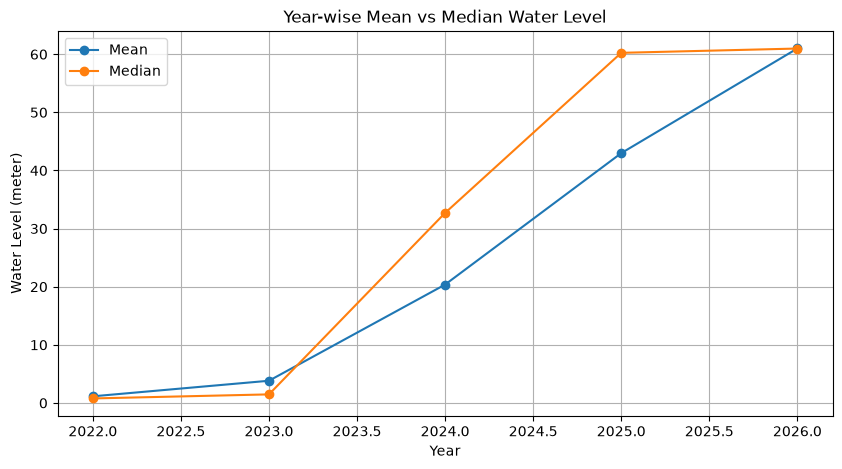

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(yearly_mean.index, yearly_mean.values, marker="o", label="Mean")
plt.plot(yearly_median.index, yearly_median.values, marker="o", label="Median")

plt.xlabel("Year")
plt.ylabel("Water Level (meter)")
plt.title("Year-wise Mean vs Median Water Level")

plt.legend()
plt.grid(True)

plt.show()

In [35]:
print("=" * 70)
print("MONTH-WISE WATER LEVEL TREND")
print("=" * 70)

monthly_mean = df.groupby(
    df["Data Acquisition Time"].dt.month
)[water_col].mean()

print("\nMonth-wise Mean Water Level:")
print(monthly_mean)

MONTH-WISE WATER LEVEL TREND

Month-wise Mean Water Level:
Data Acquisition Time
1     17.985749
2     17.750111
3     18.107458
4     16.239805
5     31.932098
6     17.295504
7     15.984577
8     18.257195
9     17.854096
10    17.981241
11    17.202825
12    16.721415
Name: River Water Level Telemetry Hourly (meter), dtype: float64


In [36]:
print("=" * 70)
print("MONTH-WISE MEDIAN WATER LEVEL")
print("=" * 70)

monthly_median = df.groupby(
    df["Data Acquisition Time"].dt.month
)[water_col].median()

print("\nMonth-wise Median Water Level:")
print(monthly_median)

MONTH-WISE MEDIAN WATER LEVEL

Month-wise Median Water Level:
Data Acquisition Time
1      5.763
2      5.763
3      5.763
4      5.763
5     32.700
6      5.763
7      5.763
8      5.763
9      5.763
10     5.763
11     5.763
12     5.763
Name: River Water Level Telemetry Hourly (meter), dtype: float64


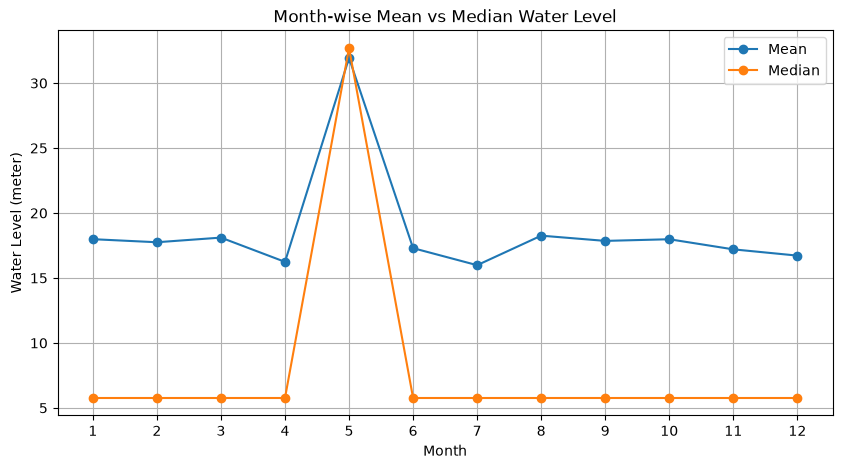

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_mean.index,
    monthly_mean.values,
    marker="o",
    label="Mean"
)

plt.plot(
    monthly_median.index,
    monthly_median.values,
    marker="o",
    label="Median"
)

plt.xlabel("Month")
plt.ylabel("Water Level (meter)")
plt.title("Month-wise Mean vs Median Water Level")

plt.xticks(range(1, 13))

plt.legend()
plt.grid(True)

plt.show()

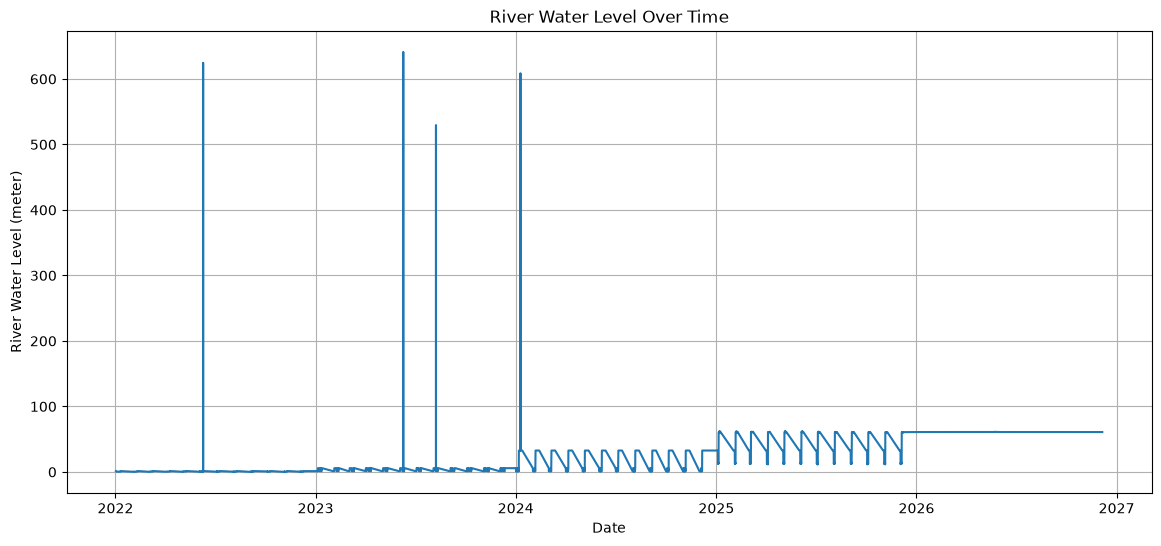

In [38]:
plt.figure(figsize=(14, 6))

plt.plot(
    df["Data Acquisition Time"],
    df[water_col]
)

plt.xlabel("Date")
plt.ylabel("River Water Level (meter)")
plt.title("River Water Level Over Time")

plt.grid(True)

plt.show()

TIME-SERIES WITHOUT EXTREME VALUES


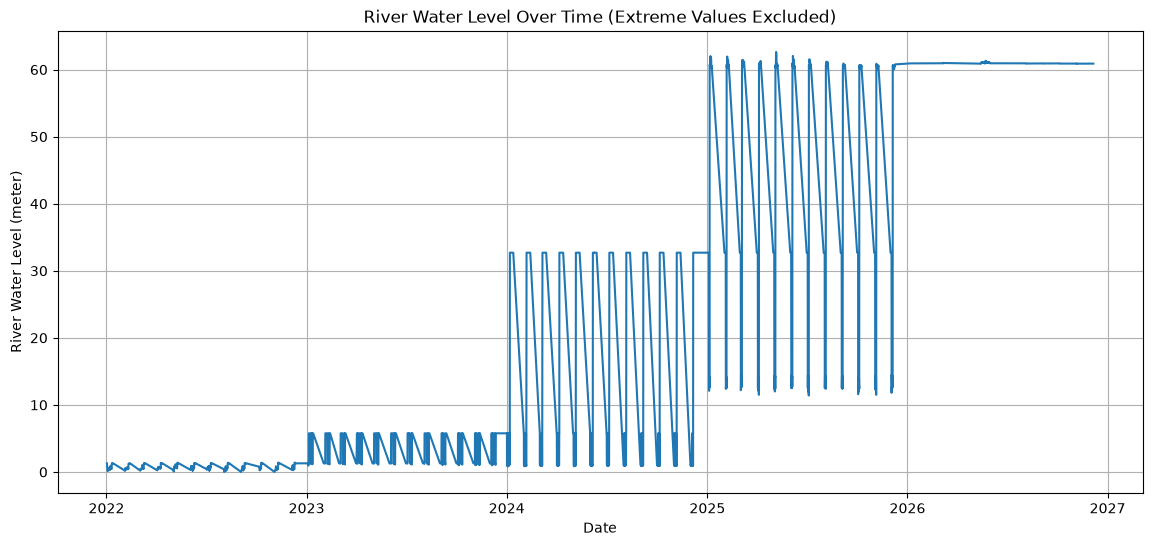

In [39]:
print("=" * 70)
print("TIME-SERIES WITHOUT EXTREME VALUES")
print("=" * 70)

normal_df = df[df[water_col] <= 100]

plt.figure(figsize=(14, 6))

plt.plot(
    normal_df["Data Acquisition Time"],
    normal_df[water_col]
)

plt.xlabel("Date")
plt.ylabel("River Water Level (meter)")
plt.title("River Water Level Over Time (Extreme Values Excluded)")

plt.grid(True)

plt.show()

<Figure size 1000x600 with 0 Axes>

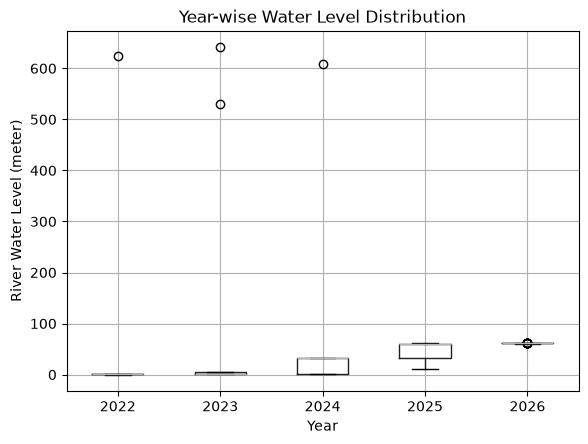

In [41]:
df["Year"] = df["Data Acquisition Time"].dt.year

plt.figure(figsize=(10, 6))

df.boxplot(
    column=water_col,
    by="Year"
)

plt.xlabel("Year")
plt.ylabel("River Water Level (meter)")
plt.title("Year-wise Water Level Distribution")

plt.suptitle("")

plt.grid(True)

plt.show()

<Figure size 1000x600 with 0 Axes>

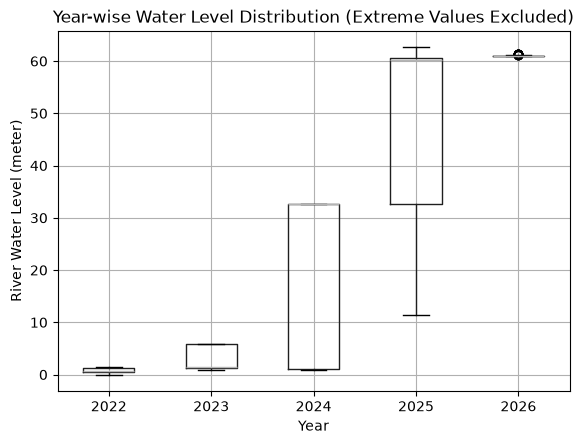

In [42]:
normal_df = df[df[water_col] <= 100]

plt.figure(figsize=(10, 6))

normal_df.boxplot(
    column=water_col,
    by="Year"
)

plt.xlabel("Year")
plt.ylabel("River Water Level (meter)")
plt.title("Year-wise Water Level Distribution (Extreme Values Excluded)")

plt.suptitle("")

plt.grid(True)

plt.show()

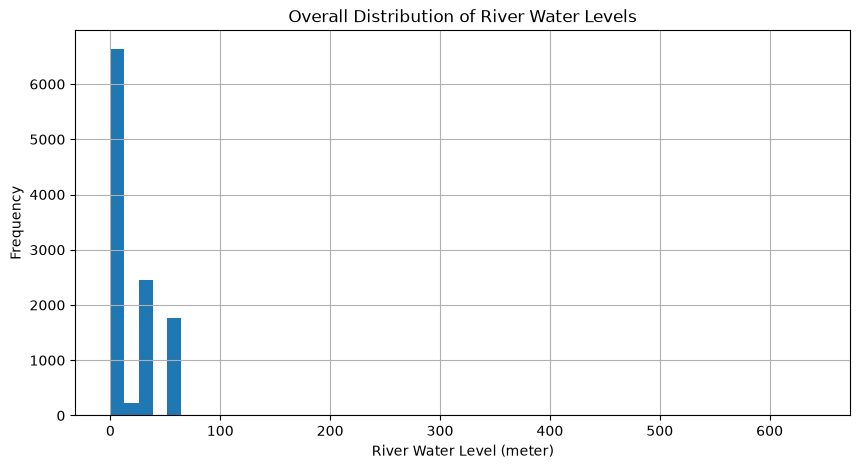

In [43]:
plt.figure(figsize=(10, 5))

plt.hist(
    df[water_col].dropna(),
    bins=50
)

plt.xlabel("River Water Level (meter)")
plt.ylabel("Frequency")
plt.title("Overall Distribution of River Water Levels")

plt.grid(True)

plt.show()

WATER LEVEL DISTRIBUTION WITHOUT EXTREME VALUES

Number of Readings:
11075

Minimum:
0.001

Maximum:
62.636


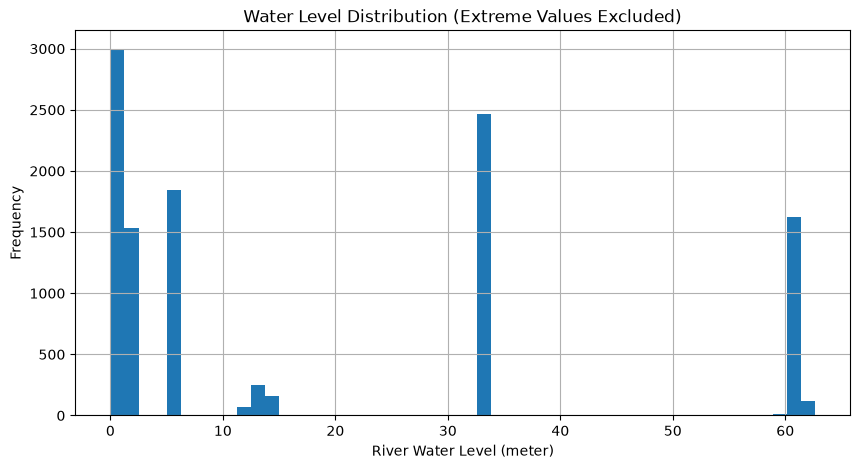

In [44]:
print("=" * 70)
print("WATER LEVEL DISTRIBUTION WITHOUT EXTREME VALUES")
print("=" * 70)

normal_water = df.loc[
    df[water_col] <= 100,
    water_col
].dropna()

print("\nNumber of Readings:")
print(len(normal_water))

print("\nMinimum:")
print(normal_water.min())

print("\nMaximum:")
print(normal_water.max())

plt.figure(figsize=(10, 5))

plt.hist(
    normal_water,
    bins=50
)

plt.xlabel("River Water Level (meter)")
plt.ylabel("Frequency")
plt.title("Water Level Distribution (Extreme Values Excluded)")

plt.grid(True)

plt.show()

In [45]:
print("=" * 70)
print("STATION-WISE WATER LEVEL ANALYSIS")
print("=" * 70)

station_stats = df.groupby("Station")[water_col].agg(
    ["count", "mean", "median", "min", "max"]
).sort_values("count", ascending=False)

print(station_stats.head(20))


STATION-WISE WATER LEVEL ANALYSIS
                                count       mean  median    min      max
Station                                                                 
NH15 Crossing Fakirpara Tangni  11079  19.076142   5.763  0.001  641.231


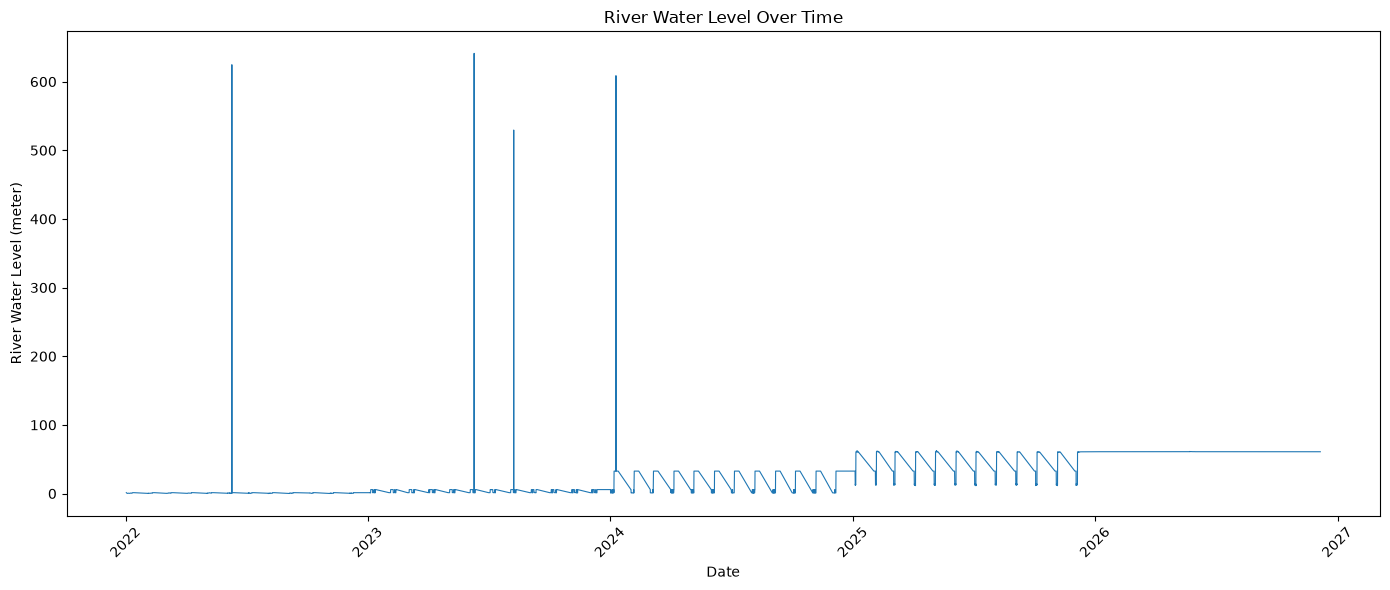

In [46]:
plt.figure(figsize=(14, 6))

plt.plot(
    df["Data Acquisition Time"],
    df[water_col],
    linewidth=0.8
)

plt.xlabel("Date")
plt.ylabel("River Water Level (meter)")
plt.title("River Water Level Over Time")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [47]:
print("=" * 70)
print("YEAR-WISE READING COUNT")
print("=" * 70)

year_count = df.groupby(
    df["Data Acquisition Time"].dt.year
)[water_col].count()

print(year_count)

YEAR-WISE READING COUNT
Data Acquisition Time
2022    1976
2023    3070
2024    3238
2025    2169
2026     626
Name: River Water Level Telemetry Hourly (meter), dtype: int64


In [48]:
print("=" * 70)
print("YEAR-WISE DATA COVERAGE")
print("=" * 70)

year_coverage = (
    df.groupby(df["Data Acquisition Time"].dt.year)[water_col]
    .agg(["count"])
)

year_coverage["Expected_Readings"] = [
    8760,   # 2022
    8760,   # 2023
    8784,   # 2024 (leap year)
    8760,   # 2025
    8760    # 2026
]

year_coverage["Coverage_Percentage"] = (
    year_coverage["count"]
    / year_coverage["Expected_Readings"]
    * 100
)

print(year_coverage)

YEAR-WISE DATA COVERAGE
                       count  Expected_Readings  Coverage_Percentage
Data Acquisition Time                                               
2022                    1976               8760            22.557078
2023                    3070               8760            35.045662
2024                    3238               8784            36.862477
2025                    2169               8760            24.760274
2026                     626               8760             7.146119


In [49]:
print("=" * 70)
print("FINAL EDA SUMMARY")
print("=" * 70)

print("\nTotal Rows:", len(df))

print("Valid Water Level Readings:", df[water_col].notna().sum())

print("Missing Water Level Readings:", df[water_col].isna().sum())

print("Unique Stations:", df["Station"].nunique())

print("Station(s):")
print(df["Station"].unique())

print("\nDate Range:")
print(df["Data Acquisition Time"].min(), "to", df["Data Acquisition Time"].max())

print("\nWater Level Range:")
print(df[water_col].min(), "to", df[water_col].max())

print("\nMedian Water Level:")
print(df[water_col].median())

print("\nMean Water Level:")
print(df[water_col].mean())

print("\nExtreme Values (>100 m):")
print((df[water_col] > 100).sum())

print("\nDuplicate Timestamps:")
print(df["Data Acquisition Time"].duplicated().sum())

FINAL EDA SUMMARY

Total Rows: 11124
Valid Water Level Readings: 11079
Missing Water Level Readings: 45
Unique Stations: 1
Station(s):
<StringArray>
['NH15 Crossing Fakirpara Tangni']
Length: 1, dtype: str

Date Range:
2022-01-01 20:00:00 to 2026-12-05 22:00:00

Water Level Range:
0.001 to 641.231

Median Water Level:
5.763

Mean Water Level:
19.076142333460755

Extreme Values (>100 m):
4

Duplicate Timestamps:
0


In [3]:
print("=" * 70)
print("DATE RANGE VALIDATION")
print("=" * 70)

# Make sure datetime column is actually datetime
df["Data Acquisition Time"] = pd.to_datetime(
    df["Data Acquisition Time"],
    errors="coerce"
)

print("\nMinimum Date:")
print(df["Data Acquisition Time"].min())

print("\nMaximum Date:")
print(df["Data Acquisition Time"].max())

DATE RANGE VALIDATION

Minimum Date:
2022-01-01 20:00:00

Maximum Date:
2026-12-05 22:00:00


In [5]:
print("=" * 70)
print("SUSPICIOUS FUTURE DATE RECORDS")
print("=" * 70)

future_data = df[
    df["Data Acquisition Time"] > "2026-06-03 23:59:59"
]

print("\nTotal Suspicious Records:")
print(len(future_data))

print("\nDate Range:")
print("Minimum:", future_data["Data Acquisition Time"].min())
print("Maximum:", future_data["Data Acquisition Time"].max())

print("\nStation:")
print(future_data["Station"].unique())

print("\nWater Level Statistics:")
print(
    future_data["River Water Level Telemetry Hourly (meter)"].describe()
)

print("\nSample Records:")
print(
    future_data[
        [
            "Data Acquisition Time",
            "Station",
            "District",
            "River Water Level Telemetry Hourly (meter)"
        ]
    ].head(20)
)

SUSPICIOUS FUTURE DATE RECORDS

Total Suspicious Records:
122

Date Range:
Minimum: 2026-07-05 20:00:00
Maximum: 2026-12-05 22:00:00

Station:
<StringArray>
['NH15 Crossing Fakirpara Tangni']
Length: 1, dtype: str

Water Level Statistics:
count    122.000000
mean      60.913172
std        0.018477
min       60.882000
25%       60.896250
50%       60.912000
75%       60.928000
max       60.949000
Name: River Water Level Telemetry Hourly (meter), dtype: float64

Sample Records:
      Data Acquisition Time                         Station District  \
11002   2026-07-05 20:00:00  NH15 Crossing Fakirpara Tangni  DARRANG   
11003   2026-07-05 21:00:00  NH15 Crossing Fakirpara Tangni  DARRANG   
11004   2026-07-05 22:00:00  NH15 Crossing Fakirpara Tangni  DARRANG   
11005   2026-07-05 23:00:00  NH15 Crossing Fakirpara Tangni  DARRANG   
11006   2026-08-05 00:00:00  NH15 Crossing Fakirpara Tangni  DARRANG   
11007   2026-08-05 01:00:00  NH15 Crossing Fakirpara Tangni  DARRANG   
11008   2026-08

In [6]:
print("=" * 70)
print("RAW DATE FORMAT CHECK")
print("=" * 70)

raw_df = pd.read_csv(
    r"D:\document\Brahmaputra-FloodCast\data\final\darrang_water_level_final.csv",
    dtype={"Data Acquisition Time": "string"}
)

print("\nRaw Date Data Type:")
print(raw_df["Data Acquisition Time"].dtype)

print("\nFirst 10 Raw Dates:")
print(raw_df["Data Acquisition Time"].head(10).to_string(index=False))

print("\nLast 20 Raw Dates:")
print(raw_df["Data Acquisition Time"].tail(20).to_string(index=False))

RAW DATE FORMAT CHECK

Raw Date Data Type:
string

First 10 Raw Dates:
2022-01-01 20:00:00
2022-01-03 00:00:00
2022-01-03 01:00:00
2022-01-03 02:00:00
2022-01-03 03:00:00
2022-01-03 04:00:00
2022-01-03 05:00:00
2022-01-03 06:00:00
2022-01-03 07:00:00
2022-01-03 08:00:00

Last 20 Raw Dates:
2026-12-05 02:00:00
2026-12-05 03:00:00
2026-12-05 04:00:00
2026-12-05 05:00:00
2026-12-05 06:00:00
2026-12-05 07:00:00
2026-12-05 08:00:00
2026-12-05 09:00:00
2026-12-05 10:00:00
2026-12-05 11:00:00
2026-12-05 12:00:00
2026-12-05 13:00:00
2026-12-05 14:00:00
2026-12-05 15:00:00
2026-12-05 16:00:00
2026-12-05 17:00:00
2026-12-05 18:00:00
2026-12-05 19:00:00
2026-12-05 20:00:00
2026-12-05 22:00:00


In [7]:
print("=" * 70)
print("RAW SUSPICIOUS RECORDS")
print("=" * 70)

raw_df["Parsed_Date"] = pd.to_datetime(
    raw_df["Data Acquisition Time"],
    errors="coerce"
)

raw_suspicious = raw_df[
    raw_df["Parsed_Date"] > "2026-06-03 23:59:59"
]

print("\nTotal Suspicious Records:")
print(len(raw_suspicious))

print("\nSuspicious Date Range:")
print(raw_suspicious["Parsed_Date"].min())
print(raw_suspicious["Parsed_Date"].max())

print("\nSuspicious Records:")
print(
    raw_suspicious[
        [
            "Data Acquisition Time",
            "Parsed_Date",
            "Station",
            "District",
            "River Water Level Telemetry Hourly (meter)"
        ]
    ].head(30).to_string(index=False)
)

RAW SUSPICIOUS RECORDS

Total Suspicious Records:
122

Suspicious Date Range:
2026-07-05 20:00:00
2026-12-05 22:00:00

Suspicious Records:
Data Acquisition Time         Parsed_Date                        Station District  River Water Level Telemetry Hourly (meter)
  2026-07-05 20:00:00 2026-07-05 20:00:00 NH15 Crossing Fakirpara Tangni  DARRANG                                      60.937
  2026-07-05 21:00:00 2026-07-05 21:00:00 NH15 Crossing Fakirpara Tangni  DARRANG                                      60.941
  2026-07-05 22:00:00 2026-07-05 22:00:00 NH15 Crossing Fakirpara Tangni  DARRANG                                      60.940
  2026-07-05 23:00:00 2026-07-05 23:00:00 NH15 Crossing Fakirpara Tangni  DARRANG                                      60.940
  2026-08-05 00:00:00 2026-08-05 00:00:00 NH15 Crossing Fakirpara Tangni  DARRANG                                      60.938
  2026-08-05 01:00:00 2026-08-05 01:00:00 NH15 Crossing Fakirpara Tangni  DARRANG                        

In [8]:
import os

print("=" * 70)
print("RAW DATA FILES")
print("=" * 70)

for root, dirs, files in os.walk(
    r"D:\document\Brahmaputra-FloodCast\data\raw"
):
    for file in files:
        print(os.path.join(root, file))

RAW DATA FILES
D:\document\Brahmaputra-FloodCast\data\raw\assam_water_level_2021_2025.csv
D:\document\Brahmaputra-FloodCast\data\raw\darrang_api1_raw.csv
D:\document\Brahmaputra-FloodCast\data\raw\darrang_api2_raw.csv


In [9]:
print("=" * 70)
print("API 2 RAW DATA DATE RANGE")
print("=" * 70)

api2 = pd.read_csv(
    r"D:\document\Brahmaputra-FloodCast\data\raw\darrang_api2_raw.csv"
)

print("\nRows:")
print(len(api2))

print("\nColumns:")
print(api2.columns.tolist())

print("\nFirst 5 rows:")
print(api2.head())

API 2 RAW DATA DATE RANGE

Rows:
626

Columns:
['_id', 'SlNo', 'Station', 'Agency', 'State LGD Code', 'State', 'District LGD Code', 'District', 'Tehsil', 'Block', 'Village', 'River', 'Basin', 'Tributary', 'Subtributary', 'SubSubtributary', 'Local River', 'Latitude', 'Longitude', 'Is_DischargeDataAvailable', 'RL_of_zeroGauge', 'MeanSeaLevel', 'Data Acquisition Time', 'River Water Level Telemetry Hourly (meter)']

First 5 rows:
   _id  SlNo                         Station Agency  State LGD Code  State  \
0    1     1  NH15 Crossing Fakirpara Tangni  Assam              18  Assam   
1    2     2  NH15 Crossing Fakirpara Tangni  Assam              18  Assam   
2    3     3  NH15 Crossing Fakirpara Tangni  Assam              18  Assam   
3    4     4  NH15 Crossing Fakirpara Tangni  Assam              18  Assam   
4    5     5  NH15 Crossing Fakirpara Tangni  Assam              18  Assam   

   District LGD Code District Tehsil Block  ... Subtributary SubSubtributary  \
0                283 

In [11]:
api2 = pd.read_csv(
    r"D:\document\Brahmaputra-FloodCast\data\raw\darrang_api2_raw.csv"
)

api2["Data Acquisition Time"] = pd.to_datetime(
    api2["Data Acquisition Time"],
    dayfirst=True,
    errors="coerce"
)

print(api2["Data Acquisition Time"].min())
print(api2["Data Acquisition Time"].max())

2026-05-07 20:00:00
2026-06-03 23:00:00


In [12]:
api1 = pd.read_csv(
    r"D:\document\Brahmaputra-FloodCast\data\raw\darrang_api1_raw.csv"
)

api1["Data Acquisition Time"] = pd.to_datetime(
    api1["Data Acquisition Time"],
    errors="coerce"
)

print(api1["Data Acquisition Time"].min())
print(api1["Data Acquisition Time"].max())

2022-01-01 20:00:00
2025-12-09 11:00:00


In [13]:
combined_df = pd.concat(
    [api1, api2],
    ignore_index=True
)

print("Rows:", len(combined_df))
print("Columns:", len(combined_df.columns))

print(
    combined_df[
        ["Data Acquisition Time", "Station",
         "River Water Level Telemetry Hourly (meter)"]
    ].tail(10)
)

Rows: 37086
Columns: 24
      Data Acquisition Time                         Station  \
37076   2026-06-03 14:00:00  NH15 Crossing Fakirpara Tangni   
37077   2026-06-03 15:00:00  NH15 Crossing Fakirpara Tangni   
37078   2026-06-03 16:00:00  NH15 Crossing Fakirpara Tangni   
37079   2026-06-03 17:00:00  NH15 Crossing Fakirpara Tangni   
37080   2026-06-03 18:00:00  NH15 Crossing Fakirpara Tangni   
37081   2026-06-03 19:00:00  NH15 Crossing Fakirpara Tangni   
37082   2026-06-03 20:00:00  NH15 Crossing Fakirpara Tangni   
37083   2026-06-03 21:00:00  NH15 Crossing Fakirpara Tangni   
37084   2026-06-03 22:00:00  NH15 Crossing Fakirpara Tangni   
37085   2026-06-03 23:00:00  NH15 Crossing Fakirpara Tangni   

       River Water Level Telemetry Hourly (meter)  
37076                                      60.955  
37077                                      60.952  
37078                                      60.957  
37079                                      60.965  
37080                 

In [14]:
duplicate_count = combined_df[
    "Data Acquisition Time"
].duplicated().sum()

print("Duplicate Timestamps:", duplicate_count)

Duplicate Timestamps: 25961


In [15]:
print("Minimum Date:")
print(combined_df["Data Acquisition Time"].min())

print("\nMaximum Date:")
print(combined_df["Data Acquisition Time"].max())

Minimum Date:
2022-01-01 20:00:00

Maximum Date:
2026-06-03 23:00:00


In [17]:
import pandas as pd

API1_PATH = r"D:\document\Brahmaputra-FloodCast\data\cleaned\darrang_api1_clean.csv"
API2_PATH = r"D:\document\Brahmaputra-FloodCast\data\cleaned\darrang_api2_clean.csv"

# Load cleaned files
api1 = pd.read_csv(API1_PATH)
api2 = pd.read_csv(API2_PATH)

# Correct date parsing
api1["Data Acquisition Time"] = pd.to_datetime(
    api1["Data Acquisition Time"],
    errors="coerce"
)

api2["Data Acquisition Time"] = pd.to_datetime(
    api2["Data Acquisition Time"],
    dayfirst=True,
    errors="coerce"
)

# Combine
df_final = pd.concat(
    [api1, api2],
    ignore_index=True
)

# Sort
df_final = df_final.sort_values(
    "Data Acquisition Time"
).reset_index(drop=True)

print("=" * 70)
print("CORRECTED COMBINED DATASET")
print("=" * 70)

print("\nRows:", len(df_final))
print("Columns:", len(df_final.columns))

print("\nMinimum Date:")
print(df_final["Data Acquisition Time"].min())

print("\nMaximum Date:")
print(df_final["Data Acquisition Time"].max())

CORRECTED COMBINED DATASET

Rows: 11124
Columns: 24

Minimum Date:
2022-01-01 20:00:00

Maximum Date:
2026-06-03 23:00:00


In [18]:
print("=" * 70)
print("DUPLICATE TIMESTAMP ANALYSIS")
print("=" * 70)

timestamp_counts = (
    df_final["Data Acquisition Time"]
    .value_counts()
    .sort_values(ascending=False)
)

print("\nMost Repeated Timestamps:")
print(timestamp_counts.head(20))

print("\nMaximum Repetitions of Any Timestamp:")
print(timestamp_counts.max())

DUPLICATE TIMESTAMP ANALYSIS

Most Repeated Timestamps:
Data Acquisition Time
2022-01-01 20:00:00    1
2022-01-03 00:00:00    1
2022-01-03 01:00:00    1
2022-01-03 02:00:00    1
2022-01-03 03:00:00    1
2022-01-03 04:00:00    1
2022-01-03 05:00:00    1
2022-01-03 06:00:00    1
2022-01-03 07:00:00    1
2022-01-03 08:00:00    1
2022-01-03 09:00:00    1
2022-01-03 10:00:00    1
2022-01-03 11:00:00    1
2022-01-03 12:00:00    1
2022-01-03 13:00:00    1
2022-01-03 14:00:00    1
2022-01-03 15:00:00    1
2022-01-03 16:00:00    1
2022-01-03 17:00:00    1
2022-01-03 18:00:00    1
Name: count, dtype: int64

Maximum Repetitions of Any Timestamp:
1


In [19]:
print("=" * 70)
print("API-WISE DUPLICATE CHECK")
print("=" * 70)

print("\nAPI 1 Rows:", len(api1))
print("API 2 Rows:", len(api2))

print("\nAPI 1 Duplicate Timestamps:")
print(
    api1["Data Acquisition Time"].duplicated().sum()
)

print("\nAPI 2 Duplicate Timestamps:")
print(
    api2["Data Acquisition Time"].duplicated().sum()
)

API-WISE DUPLICATE CHECK

API 1 Rows: 10498
API 2 Rows: 626

API 1 Duplicate Timestamps:
0

API 2 Duplicate Timestamps:
432


In [21]:
print("=" * 70)
print("API 2 DUPLICATE TIMESTAMP DETAILS")
print("=" * 70)

water_col = "River Water Level Telemetry Hourly (meter)"

api2_duplicate_rows = api2[
    api2["Data Acquisition Time"].duplicated(keep=False)
].sort_values("Data Acquisition Time")

print("\nTotal duplicate rows:")
print(len(api2_duplicate_rows))

print("\nFirst 30 duplicate records:")

print(
    api2_duplicate_rows[
        [
            "Data Acquisition Time",
            "Station",
            "District",
            water_col
        ]
    ].head(30)
)

API 2 DUPLICATE TIMESTAMP DETAILS

Total duplicate rows:
433

First 30 duplicate records:
    Data Acquisition Time                         Station District  \
71                    NaT  NH15 Crossing Fakirpara Tangni  DARRANG   
72                    NaT  NH15 Crossing Fakirpara Tangni  DARRANG   
73                    NaT  NH15 Crossing Fakirpara Tangni  DARRANG   
74                    NaT  NH15 Crossing Fakirpara Tangni  DARRANG   
75                    NaT  NH15 Crossing Fakirpara Tangni  DARRANG   
76                    NaT  NH15 Crossing Fakirpara Tangni  DARRANG   
77                    NaT  NH15 Crossing Fakirpara Tangni  DARRANG   
78                    NaT  NH15 Crossing Fakirpara Tangni  DARRANG   
79                    NaT  NH15 Crossing Fakirpara Tangni  DARRANG   
80                    NaT  NH15 Crossing Fakirpara Tangni  DARRANG   
81                    NaT  NH15 Crossing Fakirpara Tangni  DARRANG   
82                    NaT  NH15 Crossing Fakirpara Tangni  DARRANG   


In [22]:
print("=" * 70)
print("API 2 RAW DATE CHECK")
print("=" * 70)

api2_raw = pd.read_csv(
    r"D:\document\Brahmaputra-FloodCast\data\raw\darrang_api2_raw.csv"
)

print("\nRows:", len(api2_raw))

print("\nRaw Date Column:")
print(api2_raw["Data Acquisition Time"].head(20))

print("\nRaw Date Data Type:")
print(api2_raw["Data Acquisition Time"].dtype)

print("\nMissing Raw Dates:")
print(api2_raw["Data Acquisition Time"].isna().sum())

API 2 RAW DATE CHECK

Rows: 626

Raw Date Column:
0     07-05-2026 20:00
1     07-05-2026 21:00
2     07-05-2026 22:00
3     07-05-2026 23:00
4     08-05-2026 00:00
5     08-05-2026 01:00
6     08-05-2026 02:00
7     08-05-2026 03:00
8     08-05-2026 04:00
9     08-05-2026 05:00
10    08-05-2026 06:00
11    08-05-2026 07:00
12    08-05-2026 08:00
13    08-05-2026 09:00
14    08-05-2026 10:00
15    08-05-2026 11:00
16    08-05-2026 12:00
17    08-05-2026 13:00
18    08-05-2026 14:00
19    08-05-2026 15:00
Name: Data Acquisition Time, dtype: str

Raw Date Data Type:
str

Missing Raw Dates:
0


In [23]:
print("=" * 70)
print("CORRECT API 2 DATE PARSING")
print("=" * 70)

api2["Data Acquisition Time"] = pd.to_datetime(
    api2["Data Acquisition Time"],
    format="%d-%m-%Y %H:%M",
    errors="coerce"
)

print("\nParsed Date Data Type:")
print(api2["Data Acquisition Time"].dtype)

print("\nMissing Dates After Parsing:")
print(api2["Data Acquisition Time"].isna().sum())

print("\nMinimum Date:")
print(api2["Data Acquisition Time"].min())

print("\nMaximum Date:")
print(api2["Data Acquisition Time"].max())

print("\nFirst 5 Dates:")
print(api2["Data Acquisition Time"].head())

CORRECT API 2 DATE PARSING

Parsed Date Data Type:
datetime64[us]

Missing Dates After Parsing:
433

Minimum Date:
2026-05-07 20:00:00

Maximum Date:
2026-06-03 23:00:00

First 5 Dates:
0   2026-06-01 00:00:00
1   2026-06-01 01:00:00
2   2026-06-01 02:00:00
3   2026-06-01 03:00:00
4   2026-06-01 04:00:00
Name: Data Acquisition Time, dtype: datetime64[us]


In [24]:
import pandas as pd

# RAW API 2 ko fresh load karo
api2_raw_fresh = pd.read_csv(
    r"D:\document\Brahmaputra-FloodCast\data\raw\darrang_api2_raw.csv"
)

print("Rows:", len(api2_raw_fresh))
print("Raw date type:", api2_raw_fresh["Data Acquisition Time"].dtype)

print("\nFirst 5 RAW dates:")
print(api2_raw_fresh["Data Acquisition Time"].head())

Rows: 626
Raw date type: str

First 5 RAW dates:
0    07-05-2026 20:00
1    07-05-2026 21:00
2    07-05-2026 22:00
3    07-05-2026 23:00
4    08-05-2026 00:00
Name: Data Acquisition Time, dtype: str


In [25]:
api2_clean = api2_raw_fresh.copy()

api2_clean["Parsed_Date"] = pd.to_datetime(
    api2_clean["Data Acquisition Time"],
    format="%d-%m-%Y %H:%M"
)

print("Rows:", len(api2_clean))
print("Missing Parsed Dates:", api2_clean["Parsed_Date"].isna().sum())
print("Minimum Date:", api2_clean["Parsed_Date"].min())
print("Maximum Date:", api2_clean["Parsed_Date"].max())

Rows: 626
Missing Parsed Dates: 0
Minimum Date: 2026-05-07 20:00:00
Maximum Date: 2026-06-03 23:00:00


In [26]:
print("=" * 70)
print("API 2 DUPLICATE TIMESTAMP CHECK")
print("=" * 70)

duplicate_count = api2_clean["Parsed_Date"].duplicated().sum()

print("\nAPI 2 Rows:", len(api2_clean))
print("Duplicate Timestamps:", duplicate_count)
print("Unique Timestamps:", api2_clean["Parsed_Date"].nunique())

API 2 DUPLICATE TIMESTAMP CHECK

API 2 Rows: 626
Duplicate Timestamps: 0
Unique Timestamps: 626


In [27]:
# API 1 + corrected API 2 combine

api1_clean = api1.copy()

# API 1 already parsed date ko same column mein rakho
api1_clean["Data Acquisition Time"] = pd.to_datetime(
    api1_clean["Data Acquisition Time"],
    errors="coerce"
)

# API 2 ke parsed date ko original datetime column mein set karo
api2_clean["Data Acquisition Time"] = api2_clean["Parsed_Date"]

# Same columns/order ensure karo
api2_clean = api2_clean[api1_clean.columns]

# Combine
df_combined = pd.concat(
    [api1_clean, api2_clean],
    ignore_index=True
)

# Sort chronologically
df_combined = df_combined.sort_values(
    "Data Acquisition Time"
).reset_index(drop=True)

print("=" * 70)
print("NEW COMBINED DATASET")
print("=" * 70)

print("\nRows:", len(df_combined))
print("Columns:", len(df_combined.columns))
print("Minimum Date:", df_combined["Data Acquisition Time"].min())
print("Maximum Date:", df_combined["Data Acquisition Time"].max())
print("Duplicate Timestamps:",
      df_combined["Data Acquisition Time"].duplicated().sum())

NEW COMBINED DATASET

Rows: 11124
Columns: 24
Minimum Date: 2022-01-01 20:00:00
Maximum Date: 2026-06-03 23:00:00
Duplicate Timestamps: 0


In [28]:
print("=" * 70)
print("FINAL MISSING VALUE CHECK")
print("=" * 70)

missing_water = df_combined[water_col].isna().sum()

print("\nMissing Water Level Readings:", missing_water)

FINAL MISSING VALUE CHECK

Missing Water Level Readings: 45


In [29]:
# FINAL MISSING BLOCK CHECK

missing_mask = df_combined[water_col].isna()

missing_blocks = (
    missing_mask
    .astype(int)
    .groupby((missing_mask != missing_mask.shift()).cumsum())
    .agg(["sum"])
)

print("Total Missing Readings:", missing_mask.sum())

Total Missing Readings: 45


In [30]:
# Identify missing-value blocks in the final combined dataset

df_temp = df_combined.sort_values(
    "Data Acquisition Time"
).reset_index(drop=True)

missing_mask = df_temp[water_col].isna()

group_id = (
    missing_mask.ne(missing_mask.shift())
    .cumsum()
)

missing_blocks = (
    df_temp.loc[missing_mask]
    .groupby(group_id[missing_mask])
    .agg(
        Start_Time=("Data Acquisition Time", "min"),
        End_Time=("Data Acquisition Time", "max"),
        Missing_Readings=(water_col, "size")
    )
    .reset_index(drop=True)
)

print("=" * 70)
print("FINAL MISSING VALUE BLOCKS")
print("=" * 70)

print(missing_blocks)

FINAL MISSING VALUE BLOCKS
           Start_Time            End_Time  Missing_Readings
0 2022-07-05 08:00:00 2022-07-05 08:00:00                 1
1 2022-08-04 11:00:00 2022-08-04 22:00:00                10
2 2022-09-04 09:00:00 2022-09-04 23:00:00                13
3 2022-10-04 10:00:00 2022-10-05 18:00:00                13
4 2022-11-04 14:00:00 2022-11-04 17:00:00                 4
5 2022-12-04 11:00:00 2022-12-04 14:00:00                 4


In [32]:
# Create a separate cleaned dataset
df_clean = df_combined.copy()

# Make sure data is sorted by time
df_clean = df_clean.sort_values(
    "Data Acquisition Time"
).reset_index(drop=True)

# Temporarily use time as the index
df_clean = df_clean.set_index("Data Acquisition Time")

# Interpolate only short gaps (maximum 4 consecutive readings)
df_clean[water_col] = df_clean[water_col].interpolate(
    method="time",
    limit=4,
    limit_area="inside"
)

# Bring time back as a normal column
df_clean = df_clean.reset_index()

print("=" * 70)
print("SHORT-GAP MISSING VALUE HANDLING")
print("=" * 70)

print("\nMissing values before:", df_combined[water_col].isna().sum())
print("Missing values after :", df_clean[water_col].isna().sum())

SHORT-GAP MISSING VALUE HANDLING

Missing values before: 45
Missing values after : 24


In [33]:
# Compare original and cleaned datasets
comparison = df_combined[
    ["Data Acquisition Time", water_col]
].copy()

comparison["Cleaned_Water_Level"] = df_clean[water_col].values

# Values that were originally missing but got filled
filled_values = comparison[
    comparison[water_col].isna()
    & comparison["Cleaned_Water_Level"].notna()
]

print("=" * 70)
print("INTERPOLATED VALUES CHECK")
print("=" * 70)

print("\nOriginal missing values:", df_combined[water_col].isna().sum())
print("Values interpolated:", len(filled_values))
print("Remaining missing values:", df_clean[water_col].isna().sum())

print("\nInterpolated records:")
print(filled_values.to_string(index=False))

INTERPOLATED VALUES CHECK

Original missing values: 45
Values interpolated: 21
Remaining missing values: 24

Interpolated records:
Data Acquisition Time  River Water Level Telemetry Hourly (meter)  Cleaned_Water_Level
  2022-07-05 08:00:00                                         NaN             0.793000
  2022-08-04 11:00:00                                         NaN             0.240607
  2022-08-04 12:00:00                                         NaN             0.253918
  2022-08-04 13:00:00                                         NaN             0.267230
  2022-08-04 15:00:00                                         NaN             0.293852
  2022-09-04 09:00:00                                         NaN             0.247678
  2022-09-04 10:00:00                                         NaN             0.260661
  2022-09-04 12:00:00                                         NaN             0.286627
  2022-09-04 13:00:00                                         NaN             0.299610

In [34]:
# Create clean dataset from ORIGINAL combined data
df_clean = df_combined.copy()

# Sort by timestamp
df_clean = df_clean.sort_values(
    "Data Acquisition Time"
).reset_index(drop=True)

# Identify consecutive missing blocks
missing_mask = df_clean[water_col].isna()

block_id = missing_mask.ne(missing_mask.shift()).cumsum()

block_sizes = (
    missing_mask.groupby(block_id)
    .transform("sum")
)

# Only interpolate blocks containing <= 4 missing readings
short_gap_mask = missing_mask & (block_sizes <= 4)

# Create temporary series for interpolation
temp = df_clean.set_index("Data Acquisition Time")[water_col]

interpolated = temp.interpolate(
    method="time",
    limit_area="inside"
)

# Apply interpolation ONLY to short-gap positions
df_clean.loc[short_gap_mask, water_col] = (
    interpolated.loc[
        df_clean.loc[short_gap_mask, "Data Acquisition Time"]
    ].values
)

print("=" * 70)
print("CORRECTED MISSING VALUE HANDLING")
print("=" * 70)

print("\nOriginal missing values:",
      df_combined[water_col].isna().sum())

print("Remaining missing values:",
      df_clean[water_col].isna().sum())

print("Values interpolated:",
      df_combined[water_col].isna().sum()
      - df_clean[water_col].isna().sum())

CORRECTED MISSING VALUE HANDLING

Original missing values: 45
Remaining missing values: 36
Values interpolated: 9


In [35]:

# Verify remaining missing-value blocks

missing_mask = df_clean[water_col].isna()

block_id = missing_mask.ne(missing_mask.shift()).cumsum()

remaining_blocks = (
    df_clean.loc[missing_mask]
    .groupby(block_id[missing_mask])
    .agg(
        Start_Time=("Data Acquisition Time", "min"),
        End_Time=("Data Acquisition Time", "max"),
        Missing_Readings=(water_col, "size")
    )
    .reset_index(drop=True)
)

print("=" * 70)
print("REMAINING MISSING BLOCKS")
print("=" * 70)

print(remaining_blocks)


REMAINING MISSING BLOCKS
           Start_Time            End_Time  Missing_Readings
0 2022-08-04 11:00:00 2022-08-04 22:00:00                10
1 2022-09-04 09:00:00 2022-09-04 23:00:00                13
2 2022-10-04 10:00:00 2022-10-05 18:00:00                13


In [36]:
# Check extreme water-level values in cleaned dataset

extreme_mask = df_clean[water_col] > 100

extreme_data = df_clean.loc[
    extreme_mask,
    ["Data Acquisition Time", "Station", "District", water_col]
].copy()

print("=" * 70)
print("EXTREME VALUE CHECK AFTER MISSING-VALUE CLEANING")
print("=" * 70)

print("\nExtreme Values (>100 m):", len(extreme_data))

print("\nExtreme Records:")
print(extreme_data.to_string(index=False))

EXTREME VALUE CHECK AFTER MISSING-VALUE CLEANING

Extreme Values (>100 m): 4

Extreme Records:
Data Acquisition Time                        Station District  River Water Level Telemetry Hourly (meter)
  2022-06-09 21:00:00 NH15 Crossing Fakirpara Tangni  DARRANG                                     624.669
  2023-06-09 22:00:00 NH15 Crossing Fakirpara Tangni  DARRANG                                     641.231
  2023-08-08 14:00:00 NH15 Crossing Fakirpara Tangni  DARRANG                                     529.533
  2024-01-09 15:00:00 NH15 Crossing Fakirpara Tangni  DARRANG                                     608.700


In [37]:
# Check readings immediately before and after each extreme value

print("=" * 70)
print("EXTREME VALUE CONTEXT CHECK")
print("=" * 70)

extreme_indices = df_clean.index[
    df_clean[water_col] > 100
]

for idx in extreme_indices:

    print("\n" + "-" * 70)

    print("Extreme Reading:")
    print(
        df_clean.loc[
            idx,
            ["Data Acquisition Time", water_col]
        ]
    )

    print("\nPrevious Reading:")
    if idx > 0:
        print(
            df_clean.loc[
                idx - 1,
                ["Data Acquisition Time", water_col]
            ]
        )
    else:
        print("No previous reading")

    print("\nNext Reading:")
    if idx < len(df_clean) - 1:
        print(
            df_clean.loc[
                idx + 1,
                ["Data Acquisition Time", water_col]
            ]
        )
    else:
        print("No next reading")

EXTREME VALUE CONTEXT CHECK

----------------------------------------------------------------------
Extreme Reading:
Data Acquisition Time                         2022-06-09 21:00:00
River Water Level Telemetry Hourly (meter)                624.669
Name: 916, dtype: object

Previous Reading:
Data Acquisition Time                         2022-06-09 20:00:00
River Water Level Telemetry Hourly (meter)                  0.653
Name: 915, dtype: object

Next Reading:
Data Acquisition Time                         2022-06-09 22:00:00
River Water Level Telemetry Hourly (meter)                  0.641
Name: 917, dtype: object

----------------------------------------------------------------------
Extreme Reading:
Data Acquisition Time                         2023-06-09 22:00:00
River Water Level Telemetry Hourly (meter)                641.231
Name: 3476, dtype: object

Previous Reading:
Data Acquisition Time                         2023-06-09 21:00:00
River Water Level Telemetry Hourly (meter)    

In [38]:
# Replace confirmed extreme anomalies with NaN
# Then interpolate them using surrounding valid readings

extreme_mask = df_clean[water_col] > 100

print("=" * 70)
print("EXTREME VALUE CORRECTION")
print("=" * 70)

print("\nExtreme values before correction:",
      extreme_mask.sum())

# Mark confirmed sensor anomalies as missing
df_clean.loc[extreme_mask, water_col] = np.nan

# Interpolate the isolated anomalies using time
df_clean = df_clean.sort_values(
    "Data Acquisition Time"
).reset_index(drop=True)

temp = df_clean.set_index(
    "Data Acquisition Time"
)[water_col]

interpolated_water = temp.interpolate(
    method="time",
    limit_area="inside"
)

df_clean[water_col] = interpolated_water.values

print("Extreme values after correction:",
      (df_clean[water_col] > 100).sum())

print("Missing values after correction:",
      df_clean[water_col].isna().sum())

EXTREME VALUE CORRECTION

Extreme values before correction: 4
Extreme values after correction: 0
Missing values after correction: 0


In [39]:
# ================================================================
# FINAL CORRECTED CLEANING PIPELINE
# ================================================================

# Always start from ORIGINAL combined dataset
df_clean = df_combined.copy()

df_clean = df_clean.sort_values(
    "Data Acquisition Time"
).reset_index(drop=True)


# ------------------------------------------------
# STEP 1: Interpolate ONLY short missing blocks
# ------------------------------------------------

missing_mask = df_clean[water_col].isna()

block_id = missing_mask.ne(
    missing_mask.shift()
).cumsum()

block_sizes = (
    missing_mask.groupby(block_id)
    .transform("sum")
)

short_gap_mask = (
    missing_mask &
    (block_sizes <= 4)
)

# Temporary time-indexed series
temp = df_clean.set_index(
    "Data Acquisition Time"
)[water_col]

interpolated = temp.interpolate(
    method="time",
    limit_area="inside"
)

# Apply ONLY to short-gap positions
df_clean.loc[short_gap_mask, water_col] = (
    interpolated.loc[
        df_clean.loc[
            short_gap_mask,
            "Data Acquisition Time"
        ]
    ].values
)


# ------------------------------------------------
# STEP 2: Detect confirmed extreme anomalies
# ------------------------------------------------

extreme_mask = df_clean[water_col] > 100

extreme_count = extreme_mask.sum()

# Mark extreme values as missing
df_clean.loc[
    extreme_mask,
    water_col
] = np.nan


# ------------------------------------------------
# STEP 3: Interpolate ONLY isolated extreme values
# ------------------------------------------------

temp = df_clean.set_index(
    "Data Acquisition Time"
)[water_col]

interpolated = temp.interpolate(
    method="time",
    limit=1,
    limit_area="inside"
)

# Apply interpolation only to the original extreme positions
df_clean.loc[extreme_mask, water_col] = (
    interpolated.loc[
        df_clean.loc[
            extreme_mask,
            "Data Acquisition Time"
        ]
    ].values
)


# ------------------------------------------------
# FINAL CHECK
# ------------------------------------------------

print("=" * 70)
print("FINAL CLEANING CHECK")
print("=" * 70)

print("\nOriginal rows:",
      len(df_combined))

print("Original missing values:",
      df_combined[water_col].isna().sum())

print("Short-gap values interpolated:",
      short_gap_mask.sum())

print("Extreme anomalies corrected:",
      extreme_count)

print("Final missing values:",
      df_clean[water_col].isna().sum())

print("Final extreme values (>100 m):",
      (df_clean[water_col] > 100).sum())

FINAL CLEANING CHECK

Original rows: 11124
Original missing values: 45
Short-gap values interpolated: 9
Extreme anomalies corrected: 4
Final missing values: 36
Final extreme values (>100 m): 0


In [40]:
# ================================================================
# FINAL DATA QUALITY VALIDATION
# ================================================================

print("=" * 70)
print("FINAL DATA QUALITY VALIDATION")
print("=" * 70)

print("\nRows:", len(df_clean))
print("Columns:", len(df_clean.columns))

print("\nDuplicate Timestamps:",
      df_clean["Data Acquisition Time"].duplicated().sum())

print("Missing Water Level Values:",
      df_clean[water_col].isna().sum())

print("Extreme Values (>100 m):",
      (df_clean[water_col] > 100).sum())

print("\nMinimum Date:",
      df_clean["Data Acquisition Time"].min())

print("Maximum Date:",
      df_clean["Data Acquisition Time"].max())

print("\nWater Level Minimum:",
      df_clean[water_col].min())

print("Water Level Maximum:",
      df_clean[water_col].max())

print("\nUnique Stations:",
      df_clean["Station"].nunique())

print("\nWater Level Data Type:",
      df_clean[water_col].dtype)

print("Date Data Type:",
      df_clean["Data Acquisition Time"].dtype)

FINAL DATA QUALITY VALIDATION

Rows: 11124
Columns: 24

Duplicate Timestamps: 0
Missing Water Level Values: 36
Extreme Values (>100 m): 0

Minimum Date: 2022-01-01 20:00:00
Maximum Date: 2026-06-03 23:00:00

Water Level Minimum: 0.001
Water Level Maximum: 62.636

Unique Stations: 1

Water Level Data Type: float64
Date Data Type: datetime64[us]


In [41]:
# ================================================================
# SAVE FINAL CLEANED DATASET
# ================================================================

output_path = r"D:\document\Brahmaputra-FloodCast\data\cleaned\darrang_fakipara_cleaned.csv"

df_clean.to_csv(
    output_path,
    index=False
)

print("=" * 70)
print("FINAL CLEANED DATASET SAVED")
print("=" * 70)

print("\nFile:")
print(output_path)

print("\nRows:", len(df_clean))
print("Columns:", len(df_clean.columns))

FINAL CLEANED DATASET SAVED

File:
D:\document\Brahmaputra-FloodCast\data\cleaned\darrang_fakipara_cleaned.csv

Rows: 11124
Columns: 24


In [42]:
# ================================================================
# LOAD FINAL CLEANED DATASET
# ================================================================

import pandas as pd
import numpy as np

cleaned_path = r"D:\document\Brahmaputra-FloodCast\data\cleaned\darrang_fakipara_cleaned.csv"

df = pd.read_csv(cleaned_path)

df["Data Acquisition Time"] = pd.to_datetime(
    df["Data Acquisition Time"]
)

water_col = "River Water Level Telemetry Hourly (meter)"

print("=" * 70)
print("FINAL CLEANED DATASET LOADED")
print("=" * 70)

print("\nRows:", len(df))
print("Columns:", len(df.columns))
print("Missing Water Levels:", df[water_col].isna().sum())
print("Duplicate Timestamps:",
      df["Data Acquisition Time"].duplicated().sum())

print("\nDate Range:")
print(df["Data Acquisition Time"].min())
print("to")
print(df["Data Acquisition Time"].max())

FINAL CLEANED DATASET LOADED

Rows: 11124
Columns: 24
Missing Water Levels: 36
Duplicate Timestamps: 0

Date Range:
2022-01-01 20:00:00
to
2026-06-03 23:00:00


In [43]:
# ================================================================
# CREATE MODEL-READY DATASET
# ================================================================

df_model = df.dropna(
    subset=[water_col]
).copy()

df_model = df_model.sort_values(
    "Data Acquisition Time"
).reset_index(drop=True)

print("=" * 70)
print("MODEL-READY DATASET")
print("=" * 70)

print("\nOriginal rows:", len(df))

print("Original missing water levels:",
      df[water_col].isna().sum())

print("\nModel-ready rows:", len(df_model))

print("Remaining missing water levels:",
      df_model[water_col].isna().sum())

print("Duplicate timestamps:",
      df_model["Data Acquisition Time"].duplicated().sum())

MODEL-READY DATASET

Original rows: 11124
Original missing water levels: 36

Model-ready rows: 11088
Remaining missing water levels: 0
Duplicate timestamps: 0


In [44]:
# ================================================================
# TIME-BASED FEATURE ENGINEERING
# ================================================================

df_model = df_model.sort_values(
    "Data Acquisition Time"
).reset_index(drop=True)

# Extract time information
df_model["Year"] = df_model["Data Acquisition Time"].dt.year
df_model["Month"] = df_model["Data Acquisition Time"].dt.month
df_model["Day"] = df_model["Data Acquisition Time"].dt.day
df_model["Hour"] = df_model["Data Acquisition Time"].dt.hour
df_model["DayOfYear"] = df_model["Data Acquisition Time"].dt.dayofyear
df_model["DayOfWeek"] = df_model["Data Acquisition Time"].dt.dayofweek

print("=" * 70)
print("TIME-BASED FEATURES CREATED")
print("=" * 70)

print("\nNew Features:")
print([
    "Year",
    "Month",
    "Day",
    "Hour",
    "DayOfYear",
    "DayOfWeek"
])

print("\nShape:", df_model.shape)

print("\nSample:")
print(
    df_model[
        [
            "Data Acquisition Time",
            "Year",
            "Month",
            "Day",
            "Hour",
            "DayOfYear",
            "DayOfWeek"
        ]
    ].head()
)

TIME-BASED FEATURES CREATED

New Features:
['Year', 'Month', 'Day', 'Hour', 'DayOfYear', 'DayOfWeek']

Shape: (11088, 30)

Sample:
  Data Acquisition Time  Year  Month  Day  Hour  DayOfYear  DayOfWeek
0   2022-01-01 20:00:00  2022      1    1    20          1          5
1   2022-01-03 00:00:00  2022      1    3     0          3          0
2   2022-01-03 01:00:00  2022      1    3     1          3          0
3   2022-01-03 02:00:00  2022      1    3     2          3          0
4   2022-01-03 03:00:00  2022      1    3     3          3          0


In [45]:
# ================================================================
# TIME FEATURE VALIDATION
# ================================================================

print("=" * 70)
print("TIME FEATURE VALIDATION")
print("=" * 70)

time_features = [
    "Year",
    "Month",
    "Day",
    "Hour",
    "DayOfYear",
    "DayOfWeek"
]

print("\nMissing values:")
print(df_model[time_features].isna().sum())

print("\nValue ranges:")

print(
    "Year:",
    df_model["Year"].min(),
    "to",
    df_model["Year"].max()
)

print(
    "Month:",
    df_model["Month"].min(),
    "to",
    df_model["Month"].max()
)

print(
    "Day:",
    df_model["Day"].min(),
    "to",
    df_model["Day"].max()
)

print(
    "Hour:",
    df_model["Hour"].min(),
    "to",
    df_model["Hour"].max()
)

print(
    "DayOfYear:",
    df_model["DayOfYear"].min(),
    "to",
    df_model["DayOfYear"].max()
)

print(
    "DayOfWeek:",
    df_model["DayOfWeek"].min(),
    "to",
    df_model["DayOfWeek"].max()
)

TIME FEATURE VALIDATION

Missing values:
Year         0
Month        0
Day          0
Hour         0
DayOfYear    0
DayOfWeek    0
dtype: int64

Value ranges:
Year: 2022 to 2026
Month: 1 to 12
Day: 1 to 31
Hour: 0 to 23
DayOfYear: 1 to 347
DayOfWeek: 0 to 6


In [46]:
# ================================================================
# WATER LEVEL LAG FEATURES
# ================================================================

df_model["WaterLevel_Lag_1"] = (
    df_model[water_col].shift(1)
)

df_model["WaterLevel_Lag_3"] = (
    df_model[water_col].shift(3)
)

df_model["WaterLevel_Lag_6"] = (
    df_model[water_col].shift(6)
)

df_model["WaterLevel_Lag_12"] = (
    df_model[water_col].shift(12)
)

df_model["WaterLevel_Lag_24"] = (
    df_model[water_col].shift(24)
)

print("=" * 70)
print("LAG FEATURES CREATED")
print("=" * 70)

print("\nNew Features:")
print([
    "WaterLevel_Lag_1",
    "WaterLevel_Lag_3",
    "WaterLevel_Lag_6",
    "WaterLevel_Lag_12",
    "WaterLevel_Lag_24"
])

print("\nShape:", df_model.shape)

print("\nSample:")
print(
    df_model[
        [
            "Data Acquisition Time",
            water_col,
            "WaterLevel_Lag_1",
            "WaterLevel_Lag_3",
            "WaterLevel_Lag_6",
            "WaterLevel_Lag_12",
            "WaterLevel_Lag_24"
        ]
    ].head(30)
)

LAG FEATURES CREATED

New Features:
['WaterLevel_Lag_1', 'WaterLevel_Lag_3', 'WaterLevel_Lag_6', 'WaterLevel_Lag_12', 'WaterLevel_Lag_24']

Shape: (11088, 35)

Sample:
   Data Acquisition Time  River Water Level Telemetry Hourly (meter)  \
0    2022-01-01 20:00:00                                       1.275   
1    2022-01-03 00:00:00                                       0.159   
2    2022-01-03 01:00:00                                       0.158   
3    2022-01-03 02:00:00                                       0.160   
4    2022-01-03 03:00:00                                       0.161   
5    2022-01-03 04:00:00                                       0.166   
6    2022-01-03 05:00:00                                       0.175   
7    2022-01-03 06:00:00                                       0.180   
8    2022-01-03 07:00:00                                       0.186   
9    2022-01-03 08:00:00                                       0.199   
10   2022-01-03 09:00:00                

In [47]:
# ================================================================
# LAG TIME VALIDITY CHECK
# ================================================================

print("=" * 70)
print("LAG TIME VALIDITY CHECK")
print("=" * 70)

# Calculate actual time difference from previous row
df_model["TimeDiff_Hours"] = (
    df_model["Data Acquisition Time"]
    .diff()
    .dt.total_seconds()
    / 3600
)

# Check whether each lag represents the intended number of hours
lag_checks = {
    "WaterLevel_Lag_1": 1,
    "WaterLevel_Lag_3": 3,
    "WaterLevel_Lag_6": 6,
    "WaterLevel_Lag_12": 12,
    "WaterLevel_Lag_24": 24
}

print("\nTime gap distribution:")
print(
    df_model["TimeDiff_Hours"]
    .value_counts()
    .sort_index()
    .head(20)
)

print("\nLag feature availability:")
for lag_col in lag_checks:
    print(
        lag_col,
        ":",
        df_model[lag_col].notna().sum(),
        "non-null values"
    )

LAG TIME VALIDITY CHECK

Time gap distribution:
TimeDiff_Hours
0.25         1
0.75         1
1.00     10594
2.00       284
3.00        66
4.00        22
5.00        14
6.00         3
7.00        10
8.00         2
9.00         1
10.00        2
11.00        1
12.00        1
13.00        2
14.00        2
15.00        1
18.00        1
23.00        1
25.00       18
Name: count, dtype: int64

Lag feature availability:
WaterLevel_Lag_1 : 11087 non-null values
WaterLevel_Lag_3 : 11085 non-null values
WaterLevel_Lag_6 : 11082 non-null values
WaterLevel_Lag_12 : 11076 non-null values
WaterLevel_Lag_24 : 11064 non-null values


In [48]:
# ================================================================
# EXACT TIME-BASED WATER LEVEL LAG FEATURES
# ================================================================

# Remove previous shift-based lag features
lag_columns = [
    "WaterLevel_Lag_1",
    "WaterLevel_Lag_3",
    "WaterLevel_Lag_6",
    "WaterLevel_Lag_12",
    "WaterLevel_Lag_24"
]

df_model = df_model.drop(columns=lag_columns)

# Create timestamp-indexed water level series
water_level_series = (
    df_model
    .set_index("Data Acquisition Time")[water_col]
)

# Exact-time lag features
df_model["WaterLevel_Lag_1h"] = (
    water_level_series
    .reindex(
        df_model["Data Acquisition Time"] - pd.Timedelta(hours=1)
    )
    .to_numpy()
)

df_model["WaterLevel_Lag_3h"] = (
    water_level_series
    .reindex(
        df_model["Data Acquisition Time"] - pd.Timedelta(hours=3)
    )
    .to_numpy()
)

df_model["WaterLevel_Lag_6h"] = (
    water_level_series
    .reindex(
        df_model["Data Acquisition Time"] - pd.Timedelta(hours=6)
    )
    .to_numpy()
)

df_model["WaterLevel_Lag_12h"] = (
    water_level_series
    .reindex(
        df_model["Data Acquisition Time"] - pd.Timedelta(hours=12)
    )
    .to_numpy()
)

df_model["WaterLevel_Lag_24h"] = (
    water_level_series
    .reindex(
        df_model["Data Acquisition Time"] - pd.Timedelta(hours=24)
    )
    .to_numpy()
)

print("=" * 70)
print("EXACT TIME-BASED LAG FEATURES CREATED")
print("=" * 70)

print("\nNew Features:")
print([
    "WaterLevel_Lag_1h",
    "WaterLevel_Lag_3h",
    "WaterLevel_Lag_6h",
    "WaterLevel_Lag_12h",
    "WaterLevel_Lag_24h"
])

print("\nShape:", df_model.shape)

print("\nMissing values:")
print(
    df_model[
        [
            "WaterLevel_Lag_1h",
            "WaterLevel_Lag_3h",
            "WaterLevel_Lag_6h",
            "WaterLevel_Lag_12h",
            "WaterLevel_Lag_24h"
        ]
    ].isna().sum()
)

EXACT TIME-BASED LAG FEATURES CREATED

New Features:
['WaterLevel_Lag_1h', 'WaterLevel_Lag_3h', 'WaterLevel_Lag_6h', 'WaterLevel_Lag_12h', 'WaterLevel_Lag_24h']

Shape: (11088, 36)

Missing values:
WaterLevel_Lag_1h      493
WaterLevel_Lag_3h      682
WaterLevel_Lag_6h      956
WaterLevel_Lag_12h    1401
WaterLevel_Lag_24h    2186
dtype: int64


In [49]:
# ================================================================
# EXACT LAG FEATURE VALIDATION
# ================================================================

print("=" * 70)
print("EXACT LAG FEATURE VALIDATION")
print("=" * 70)

lag_features = [
    "WaterLevel_Lag_1h",
    "WaterLevel_Lag_3h",
    "WaterLevel_Lag_6h",
    "WaterLevel_Lag_12h",
    "WaterLevel_Lag_24h"
]

print("\nNon-missing values:")
print(
    df_model[lag_features]
    .notna()
    .sum()
)

print("\nMissing percentage:")
print(
    (df_model[lag_features].isna().mean() * 100)
    .round(2)
)

print("\nSample with lag features:")

print(
    df_model[
        [
            "Data Acquisition Time",
            water_col,
            "WaterLevel_Lag_1h",
            "WaterLevel_Lag_3h",
            "WaterLevel_Lag_6h",
            "WaterLevel_Lag_12h",
            "WaterLevel_Lag_24h"
        ]
    ].iloc[20:35]
)

EXACT LAG FEATURE VALIDATION

Non-missing values:
WaterLevel_Lag_1h     10595
WaterLevel_Lag_3h     10406
WaterLevel_Lag_6h     10132
WaterLevel_Lag_12h     9687
WaterLevel_Lag_24h     8902
dtype: int64

Missing percentage:
WaterLevel_Lag_1h      4.45
WaterLevel_Lag_3h      6.15
WaterLevel_Lag_6h      8.62
WaterLevel_Lag_12h    12.64
WaterLevel_Lag_24h    19.72
dtype: float64

Sample with lag features:
   Data Acquisition Time  River Water Level Telemetry Hourly (meter)  \
20   2022-01-03 19:00:00                                    0.238000   
21   2022-01-03 20:00:00                                    0.229000   
22   2022-01-03 21:00:00                                    0.221000   
23   2022-01-03 22:00:00                                    0.223000   
24   2022-01-03 23:00:00                                    0.227000   
25   2022-01-04 01:00:00                                    0.265000   
26   2022-01-04 02:00:00                                    0.284000   
27   2022-01-04 03

In [50]:
# ================================================================
# TIME-BASED ROLLING WATER LEVEL FEATURES
# ================================================================

# Create a temporary time-indexed series
rolling_data = (
    df_model[
        ["Data Acquisition Time", water_col]
    ]
    .set_index("Data Acquisition Time")
)

# 6-hour rolling mean
df_model["WaterLevel_RollingMean_6h"] = (
    rolling_data[water_col]
    .rolling("6h")
    .mean()
    .to_numpy()
)

# 12-hour rolling mean
df_model["WaterLevel_RollingMean_12h"] = (
    rolling_data[water_col]
    .rolling("12h")
    .mean()
    .to_numpy()
)

# 24-hour rolling mean
df_model["WaterLevel_RollingMean_24h"] = (
    rolling_data[water_col]
    .rolling("24h")
    .mean()
    .to_numpy()
)

# 24-hour rolling maximum
df_model["WaterLevel_RollingMax_24h"] = (
    rolling_data[water_col]
    .rolling("24h")
    .max()
    .to_numpy()
)

# 24-hour rolling minimum
df_model["WaterLevel_RollingMin_24h"] = (
    rolling_data[water_col]
    .rolling("24h")
    .min()
    .to_numpy()
)

print("=" * 70)
print("TIME-BASED ROLLING FEATURES CREATED")
print("=" * 70)

print("\nNew Features:")
print([
    "WaterLevel_RollingMean_6h",
    "WaterLevel_RollingMean_12h",
    "WaterLevel_RollingMean_24h",
    "WaterLevel_RollingMax_24h",
    "WaterLevel_RollingMin_24h"
])

print("\nShape:", df_model.shape)

print("\nMissing values:")
print(
    df_model[
        [
            "WaterLevel_RollingMean_6h",
            "WaterLevel_RollingMean_12h",
            "WaterLevel_RollingMean_24h",
            "WaterLevel_RollingMax_24h",
            "WaterLevel_RollingMin_24h"
        ]
    ].isna().sum()
)

TIME-BASED ROLLING FEATURES CREATED

New Features:
['WaterLevel_RollingMean_6h', 'WaterLevel_RollingMean_12h', 'WaterLevel_RollingMean_24h', 'WaterLevel_RollingMax_24h', 'WaterLevel_RollingMin_24h']

Shape: (11088, 41)

Missing values:
WaterLevel_RollingMean_6h     0
WaterLevel_RollingMean_12h    0
WaterLevel_RollingMean_24h    0
WaterLevel_RollingMax_24h     0
WaterLevel_RollingMin_24h     0
dtype: int64


In [51]:
# ================================================================
# ROLLING FEATURE VALIDATION
# ================================================================

rolling_features = [
    "WaterLevel_RollingMean_6h",
    "WaterLevel_RollingMean_12h",
    "WaterLevel_RollingMean_24h",
    "WaterLevel_RollingMax_24h",
    "WaterLevel_RollingMin_24h"
]

print("=" * 70)
print("ROLLING FEATURE VALIDATION")
print("=" * 70)

print("\nMissing values:")
print(df_model[rolling_features].isna().sum())

print("\nBasic statistics:")
print(
    df_model[rolling_features].describe().round(3)
)

# Check logical relationship between rolling min/mean/max
min_mean_check = (
    df_model["WaterLevel_RollingMin_24h"]
    <= df_model["WaterLevel_RollingMean_24h"]
).all()

mean_max_check = (
    df_model["WaterLevel_RollingMean_24h"]
    <= df_model["WaterLevel_RollingMax_24h"]
).all()

print("\nLogical checks:")
print("Rolling Min <= Rolling Mean:", min_mean_check)
print("Rolling Mean <= Rolling Max:", mean_max_check)

print("\nSample:")
print(
    df_model[
        [
            "Data Acquisition Time",
            water_col,
            "WaterLevel_RollingMean_6h",
            "WaterLevel_RollingMean_12h",
            "WaterLevel_RollingMean_24h",
            "WaterLevel_RollingMax_24h",
            "WaterLevel_RollingMin_24h"
        ]
    ].iloc[20:35]
)

ROLLING FEATURE VALIDATION

Missing values:
WaterLevel_RollingMean_6h     0
WaterLevel_RollingMean_12h    0
WaterLevel_RollingMean_24h    0
WaterLevel_RollingMax_24h     0
WaterLevel_RollingMin_24h     0
dtype: int64

Basic statistics:
       WaterLevel_RollingMean_6h  WaterLevel_RollingMean_12h  \
count                  11088.000                   11088.000   
mean                      18.693                      18.500   
std                       21.808                      21.622   
min                        0.001                       0.001   
25%                        1.255                       1.266   
50%                        5.763                       5.763   
75%                       32.700                      32.700   
max                       62.574                      62.462   

       WaterLevel_RollingMean_24h  WaterLevel_RollingMax_24h  \
count                   11088.000                  11088.000   
mean                       18.098                     19.83

In [52]:
# ================================================================
# WATER LEVEL TREND / RATE-OF-CHANGE FEATURES
# ================================================================

df_model["WaterLevel_Change_1h"] = (
    df_model[water_col] - df_model["WaterLevel_Lag_1h"]
)

df_model["WaterLevel_Change_3h"] = (
    df_model[water_col] - df_model["WaterLevel_Lag_3h"]
)

df_model["WaterLevel_Change_6h"] = (
    df_model[water_col] - df_model["WaterLevel_Lag_6h"]
)

df_model["WaterLevel_Change_12h"] = (
    df_model[water_col] - df_model["WaterLevel_Lag_12h"]
)

df_model["WaterLevel_Change_24h"] = (
    df_model[water_col] - df_model["WaterLevel_Lag_24h"]
)

print("=" * 70)
print("WATER LEVEL TREND FEATURES CREATED")
print("=" * 70)

trend_features = [
    "WaterLevel_Change_1h",
    "WaterLevel_Change_3h",
    "WaterLevel_Change_6h",
    "WaterLevel_Change_12h",
    "WaterLevel_Change_24h"
]

print("\nNew Features:")
print(trend_features)

print("\nShape:", df_model.shape)

print("\nMissing values:")
print(df_model[trend_features].isna().sum())

print("\nSample:")
print(
    df_model[
        [
            "Data Acquisition Time",
            water_col,
            "WaterLevel_Change_1h",
            "WaterLevel_Change_3h",
            "WaterLevel_Change_6h",
            "WaterLevel_Change_12h",
            "WaterLevel_Change_24h"
        ]
    ].iloc[20:35]
)

WATER LEVEL TREND FEATURES CREATED

New Features:
['WaterLevel_Change_1h', 'WaterLevel_Change_3h', 'WaterLevel_Change_6h', 'WaterLevel_Change_12h', 'WaterLevel_Change_24h']

Shape: (11088, 46)

Missing values:
WaterLevel_Change_1h      493
WaterLevel_Change_3h      682
WaterLevel_Change_6h      956
WaterLevel_Change_12h    1401
WaterLevel_Change_24h    2186
dtype: int64

Sample:
   Data Acquisition Time  River Water Level Telemetry Hourly (meter)  \
20   2022-01-03 19:00:00                                    0.238000   
21   2022-01-03 20:00:00                                    0.229000   
22   2022-01-03 21:00:00                                    0.221000   
23   2022-01-03 22:00:00                                    0.223000   
24   2022-01-03 23:00:00                                    0.227000   
25   2022-01-04 01:00:00                                    0.265000   
26   2022-01-04 02:00:00                                    0.284000   
27   2022-01-04 03:00:00                  

In [53]:
# ================================================================
# TREND FEATURE VALIDATION
# ================================================================

trend_features = [
    "WaterLevel_Change_1h",
    "WaterLevel_Change_3h",
    "WaterLevel_Change_6h",
    "WaterLevel_Change_12h",
    "WaterLevel_Change_24h"
]

print("=" * 70)
print("TREND FEATURE VALIDATION")
print("=" * 70)

print("\nMissing values:")
print(df_model[trend_features].isna().sum())

print("\nStatistics:")
print(
    df_model[trend_features]
    .describe()
    .round(3)
)

print("\nPositive changes:")
for col in trend_features:
    print(
        col,
        ":",
        (df_model[col] > 0).sum()
    )

print("\nNegative changes:")
for col in trend_features:
    print(
        col,
        ":",
        (df_model[col] < 0).sum()
    )

print("\nZero changes:")
for col in trend_features:
    print(
        col,
        ":",
        (df_model[col] == 0).sum()
    )

TREND FEATURE VALIDATION

Missing values:
WaterLevel_Change_1h      493
WaterLevel_Change_3h      682
WaterLevel_Change_6h      956
WaterLevel_Change_12h    1401
WaterLevel_Change_24h    2186
dtype: int64

Statistics:
       WaterLevel_Change_1h  WaterLevel_Change_3h  WaterLevel_Change_6h  \
count             10595.000             10406.000             10132.000   
mean                  0.064                 0.180                 0.370   
std                   1.930                 3.264                 4.694   
min                 -21.100               -21.100               -21.100   
25%                  -0.001                -0.005                -0.011   
50%                   0.000                 0.000                 0.000   
75%                   0.000                 0.001                 0.008   
max                  49.270                49.285                49.283   

       WaterLevel_Change_12h  WaterLevel_Change_24h  
count               9687.000               8902.000 

In [54]:
# ================================================================
# CHECK FOR FLOOD / WARNING / DANGER LEVEL INFORMATION
# ================================================================

print("=" * 70)
print("CHECKING FLOOD THRESHOLD INFORMATION")
print("=" * 70)

print("\nAll columns:")
for i, col in enumerate(df.columns, start=1):
    print(i, ":", col)

print("\nPossible threshold-related columns:")

keywords = [
    "danger",
    "warning",
    "flood",
    "threshold",
    "alert",
    "level"
]

threshold_columns = [
    col for col in df.columns
    if any(word in col.lower() for word in keywords)
]

if threshold_columns:
    print(threshold_columns)
else:
    print("No threshold-related column found.")

CHECKING FLOOD THRESHOLD INFORMATION

All columns:
1 : Data Acquisition Time
2 : _id
3 : SlNo
4 : Station
5 : Agency
6 : State LGD Code
7 : State
8 : District LGD Code
9 : District
10 : Tehsil
11 : Block
12 : Village
13 : River
14 : Basin
15 : Tributary
16 : Subtributary
17 : SubSubtributary
18 : Local River
19 : Latitude
20 : Longitude
21 : Is_DischargeDataAvailable
22 : RL_of_zeroGauge
23 : MeanSeaLevel
24 : River Water Level Telemetry Hourly (meter)

Possible threshold-related columns:
['MeanSeaLevel', 'River Water Level Telemetry Hourly (meter)']


In [55]:
# ================================================================
# CHECK STATION LEVEL INFORMATION
# ================================================================

print("=" * 70)
print("STATION LEVEL INFORMATION")
print("=" * 70)

print("\nMeanSeaLevel unique values:")
print(df["MeanSeaLevel"].unique())

print("\nRL_of_zeroGauge unique values:")
print(df["RL_of_zeroGauge"].unique())

print("\nStation:")
print(df["Station"].unique())

print("\nDistrict:")
print(df["District"].unique())

print("\nRiver:")
print(df["River"].unique())

STATION LEVEL INFORMATION

MeanSeaLevel unique values:
[0]

RL_of_zeroGauge unique values:
[0]

Station:
<StringArray>
['NH15 Crossing Fakirpara Tangni']
Length: 1, dtype: str

District:
<StringArray>
['DARRANG']
Length: 1, dtype: str

River:
<StringArray>
['-']
Length: 1, dtype: str


In [56]:
# ================================================================
# HISTORICAL WATER LEVEL DISTRIBUTION
# ================================================================

print("=" * 70)
print("HISTORICAL WATER LEVEL DISTRIBUTION")
print("=" * 70)

print("\nWater Level Statistics:")
print(
    df_model[water_col]
    .describe(
        percentiles=[
            0.50,
            0.75,
            0.90,
            0.95,
            0.97,
            0.98,
            0.99
        ]
    )
    .round(3)
)

print("\nSelected percentiles:")

percentiles = [0.90, 0.95, 0.97, 0.98, 0.99]

for p in percentiles:
    value = df_model[water_col].quantile(p)
    print(f"{int(p*100)}th percentile: {value:.3f} m")

HISTORICAL WATER LEVEL DISTRIBUTION

Water Level Statistics:
count    11088.000
mean        18.847
std         21.966
min          0.001
50%          5.763
75%         32.700
90%         60.690
95%         60.994
97%         61.073
98%         61.180
99%         61.412
max         62.636
Name: River Water Level Telemetry Hourly (meter), dtype: float64

Selected percentiles:
90th percentile: 60.690 m
95th percentile: 60.994 m
97th percentile: 61.073 m
98th percentile: 61.180 m
99th percentile: 61.412 m


In [57]:
# ================================================================
# WATER LEVEL DISTRIBUTION DIAGNOSTIC
# ================================================================

print("=" * 70)
print("WATER LEVEL DISTRIBUTION DIAGNOSTIC")
print("=" * 70)

# Exact repeated values
print("\nMost frequent water-level values:")

print(
    df_model[water_col]
    .value_counts()
    .head(20)
)

# Values around 32.7
print("\nValues around 32.7 m:")

around_32 = df_model[
    df_model[water_col].between(32.5, 32.9)
][water_col]

print("Count:", len(around_32))
print("Unique values:", around_32.nunique())

# Values above 50 m
print("\nValues above 50 m:")

above_50 = df_model[
    df_model[water_col] > 50
][water_col]

print("Count:", len(above_50))
print("Percentage:", round(len(above_50) / len(df_model) * 100, 2), "%")

# Values above 60 m
print("\nValues above 60 m:")

above_60 = df_model[
    df_model[water_col] > 60
][water_col]

print("Count:", len(above_60))
print("Percentage:", round(len(above_60) / len(df_model) * 100, 2), "%")

# Selected high-value frequencies
print("\nMost frequent values above 50 m:")

print(
    above_50
    .value_counts()
    .head(20)
)

WATER LEVEL DISTRIBUTION DIAGNOSTIC

Most frequent water-level values:
River Water Level Telemetry Hourly (meter)
32.700    2461
5.763     1842
12.600      86
12.700      81
14.100      44
1.289       43
1.290       38
1.291       35
12.500      35
1.283       34
1.286       34
1.258       34
14.200      33
1.252       32
1.260       32
14.300      32
1.284       29
1.294       28
1.287       28
1.256       27
Name: count, dtype: int64

Values around 32.7 m:
Count: 2463
Unique values: 3

Values above 50 m:
Count: 1756
Percentage: 15.84 %

Values above 60 m:
Count: 1756
Percentage: 15.84 %

Most frequent values above 50 m:
River Water Level Telemetry Hourly (meter)
60.935    12
60.942    11
60.903    10
60.636     9
60.895     8
61.045     8
60.952     8
60.948     8
60.934     8
60.900     8
61.060     8
60.987     7
60.894     7
61.000     7
60.936     7
60.927     7
60.961     6
61.015     6
60.925     6
61.051     6
Name: count, dtype: int64


In [58]:
# ================================================================
# TEMPORAL REGIME ANALYSIS
# ================================================================

print("=" * 70)
print("TEMPORAL REGIME ANALYSIS")
print("=" * 70)

# Create regime labels
def classify_level(x):
    if x <= 20:
        return "Low_Level"
    elif x <= 50:
        return "Mid_Level"
    else:
        return "High_Level"

df_model["WaterLevel_Regime"] = (
    df_model[water_col]
    .apply(classify_level)
)

print("\nRegime counts:")
print(
    df_model["WaterLevel_Regime"]
    .value_counts()
)

print("\nRegime percentages:")
print(
    (
        df_model["WaterLevel_Regime"]
        .value_counts(normalize=True) * 100
    ).round(2)
)

# Date range of high-level observations
high_level = df_model[
    df_model[water_col] > 50
]

print("\nHigh-level observations (>50 m):")
print("Count:", len(high_level))

if len(high_level) > 0:
    print(
        "First:",
        high_level["Data Acquisition Time"].min()
    )
    print(
        "Last:",
        high_level["Data Acquisition Time"].max()
    )

# Date range of 32.7 observations
level_327 = df_model[
    df_model[water_col].between(32.699, 32.701)
]

print("\n32.7 m observations:")
print("Count:", len(level_327))

if len(level_327) > 0:
    print(
        "First:",
        level_327["Data Acquisition Time"].min()
    )
    print(
        "Last:",
        level_327["Data Acquisition Time"].max()
    )

# Year-wise distribution
print("\nYear-wise regime distribution:")

print(
    pd.crosstab(
        df_model["Year"],
        df_model["WaterLevel_Regime"],
        normalize="index"
    ).round(3)
)

TEMPORAL REGIME ANALYSIS

Regime counts:
WaterLevel_Regime
Low_Level     6869
Mid_Level     2463
High_Level    1756
Name: count, dtype: int64

Regime percentages:
WaterLevel_Regime
Low_Level     61.95
Mid_Level     22.21
High_Level    15.84
Name: proportion, dtype: float64

High-level observations (>50 m):
Count: 1756
First: 2025-01-05 00:00:00
Last: 2026-06-03 23:00:00

32.7 m observations:
Count: 2462
First: 2024-01-06 15:00:00
Last: 2025-12-02 22:00:00

Year-wise regime distribution:
WaterLevel_Regime  High_Level  Low_Level  Mid_Level
Year                                               
2022                    0.000      1.000      0.000
2023                    0.000      1.000      0.000
2024                    0.000      0.411      0.589
2025                    0.521      0.223      0.256
2026                    1.000      0.000      0.000


In [59]:
# ================================================================
# YEAR-WISE WATER LEVEL ANALYSIS
# ================================================================

print("=" * 70)
print("YEAR-WISE WATER LEVEL ANALYSIS")
print("=" * 70)

year_stats = (
    df_model
    .groupby("Year")[water_col]
    .agg(
        Count="count",
        Mean="mean",
        Median="median",
        Min="min",
        Max="max",
        Std="std"
    )
    .round(3)
)

print("\nYear-wise statistics:")
print(year_stats)

print("\nYear-wise selected percentiles:")

year_percentiles = (
    df_model
    .groupby("Year")[water_col]
    .quantile(
        [0.10, 0.25, 0.50, 0.75, 0.90, 0.95]
    )
    .unstack()
    .round(3)
)

print(year_percentiles)

YEAR-WISE WATER LEVEL ANALYSIS

Year-wise statistics:
      Count    Mean  Median     Min     Max     Std
Year                                               
2022   1985   0.822   0.773   0.001   1.403   0.420
2023   3070   3.439   1.470   0.943   5.763   2.249
2024   3238  20.190  32.700   0.840  32.701  15.038
2025   2169  42.983  60.243  11.400  62.636  19.757
2026    626  60.998  60.982  60.882  61.317   0.084

Year-wise selected percentiles:
        0.10    0.25    0.50    0.75    0.90    0.95
Year                                                
2022   0.268   0.440   0.773   1.266   1.294   1.304
2023   1.161   1.262   1.470   5.763   5.763   5.763
2024   0.932   1.037  32.700  32.700  32.700  32.700
2025  12.700  32.700  60.243  60.659  61.118  61.426
2026  60.903  60.934  60.982  61.052  61.098  61.148


In [60]:
# ================================================================
# MAJOR WATER LEVEL TRANSITIONS
# ================================================================

print("=" * 70)
print("MAJOR WATER LEVEL TRANSITIONS")
print("=" * 70)

df_model["Level_Change_From_Previous"] = (
    df_model[water_col].diff()
)

large_changes = (
    df_model[
        df_model["Level_Change_From_Previous"].abs() > 10
    ][
        [
            "Data Acquisition Time",
            water_col,
            "Level_Change_From_Previous"
        ]
    ]
)

print("\nLarge level changes (>10 m):")
print(large_changes.to_string(index=False))

print("\nTotal large changes:", len(large_changes))

MAJOR WATER LEVEL TRANSITIONS

Large level changes (>10 m):
Data Acquisition Time  River Water Level Telemetry Hourly (meter)  Level_Change_From_Previous
  2024-01-06 15:00:00                                      32.700                      31.510
  2024-02-01 01:00:00                                       5.763                     -26.937
  2024-02-06 00:00:00                                      32.700                      26.937
  2024-03-01 09:00:00                                       5.763                     -26.937
  2024-03-06 00:00:00                                      32.700                      26.937
  2024-04-01 00:00:00                                       5.763                     -26.937
  2024-04-06 00:00:00                                      32.700                      26.937
  2024-05-01 01:00:00                                       5.763                     -26.937
  2024-05-06 00:00:00                                      32.700                      31.746


In [61]:
# ================================================================
# SUSPICIOUS VALUE TEMPORAL ANALYSIS
# ================================================================

print("=" * 70)
print("SUSPICIOUS WATER-LEVEL VALUE ANALYSIS")
print("=" * 70)

suspicious_values = [5.763, 32.700]

for value in suspicious_values:

    temp = df_model[
        df_model[water_col] == value
    ].copy()

    print(f"\n{'-' * 70}")
    print(f"VALUE: {value}")
    print(f"{'-' * 70}")

    print("Count:", len(temp))

    print("\nFirst 20 timestamps:")

    print(
        temp["Data Acquisition Time"]
        .head(20)
        .to_string(index=False)
    )

    print("\nLast 20 timestamps:")

    print(
        temp["Data Acquisition Time"]
        .tail(20)
        .to_string(index=False)
    )

SUSPICIOUS WATER-LEVEL VALUE ANALYSIS

----------------------------------------------------------------------
VALUE: 5.763
----------------------------------------------------------------------
Count: 1842

First 20 timestamps:
2023-01-05 00:00:00
2023-01-05 01:00:00
2023-01-05 02:00:00
2023-01-05 03:00:00
2023-01-05 04:00:00
2023-01-05 05:00:00
2023-01-05 06:00:00
2023-01-05 07:00:00
2023-01-05 08:00:00
2023-01-05 09:00:00
2023-01-05 10:00:00
2023-01-05 11:00:00
2023-01-05 12:00:00
2023-01-05 13:00:00
2023-01-05 14:00:00
2023-01-05 15:00:00
2023-01-05 16:00:00
2023-01-05 17:00:00
2023-01-05 18:00:00
2023-01-05 19:00:00

Last 20 timestamps:
2024-11-01 11:00:00
2024-11-01 12:00:00
2024-11-03 05:00:00
2024-11-03 06:00:00
2024-11-03 07:00:00
2024-11-03 08:00:00
2024-11-03 09:00:00
2024-11-03 11:00:00
2024-11-04 19:00:00
2024-11-04 20:00:00
2024-11-04 21:00:00
2024-11-04 23:00:00
2024-12-04 00:00:00
2024-12-04 01:00:00
2024-12-04 02:00:00
2024-12-04 03:00:00
2024-12-04 04:00:00
2024-12-04 

In [62]:
# ================================================================
# HIGH-LEVEL VALUE TEMPORAL ANALYSIS
# ================================================================

print("=" * 70)
print("HIGH WATER LEVEL TEMPORAL ANALYSIS")
print("=" * 70)

high = df_model[
    df_model[water_col] > 50
].copy()

high["Date"] = (
    high["Data Acquisition Time"].dt.date
)

high["YearMonth"] = (
    high["Data Acquisition Time"].dt.to_period("M")
)

print("\nHigh-level observations by month:")

print(
    high
    .groupby("YearMonth")
    .size()
    .to_string()
)

print("\nMonthly minimum / maximum:")

print(
    high
    .groupby("YearMonth")[water_col]
    .agg(["count", "min", "max", "mean"])
    .round(3)
)

HIGH WATER LEVEL TEMPORAL ANALYSIS

High-level observations by month:
YearMonth
2025-01     95
2025-02     95
2025-03     96
2025-04     88
2025-05     95
2025-06     91
2025-07     94
2025-08     93
2025-09     96
2025-10     95
2025-11     96
2025-12     96
2026-05    555
2026-06     71
Freq: M

Monthly minimum / maximum:
           count     min     max    mean
YearMonth                               
2025-01       95  60.257  61.968  61.051
2025-02       95  60.282  61.956  61.034
2025-03       96  60.260  61.457  60.900
2025-04       88  60.246  61.256  60.851
2025-05       95  60.259  62.636  61.053
2025-06       91  60.256  62.044  61.028
2025-07       94  60.261  61.554  60.801
2025-08       93  60.360  61.193  60.731
2025-09       96  60.236  60.909  60.568
2025-10       95  60.165  60.691  60.474
2025-11       96  60.033  60.878  60.479
2025-12       96  60.057  60.783  60.423
2026-05      555  60.882  61.317  61.005
2026-06       71  60.921  60.993  60.944


In [63]:
# ================================================================
# REPEATED VALUE RUN ANALYSIS
# ================================================================

print("=" * 70)
print("REPEATED VALUE RUN ANALYSIS")
print("=" * 70)

for value in [5.763, 32.700]:

    temp = df_model[
        df_model[water_col] == value
    ].copy()

    temp["New_Run"] = (
        temp[water_col] != temp[water_col].shift()
    ).cumsum()

    runs = (
        temp
        .groupby("New_Run")
        .agg(
            Value=(water_col, "first"),
            Start=("Data Acquisition Time", "first"),
            End=("Data Acquisition Time", "last"),
            Count=(water_col, "size")
        )
    )

    print(f"\nValue: {value}")

    print(
        runs
        .sort_values("Count", ascending=False)
        .head(20)
        .to_string(index=False)
    )

REPEATED VALUE RUN ANALYSIS

Value: 5.763
 Value      Start                 End  Count
 5.763 2023-01-05 2024-12-04 07:00:00   1842

Value: 32.7
 Value               Start                 End  Count
  32.7 2024-01-06 15:00:00 2025-12-02 22:00:00   2461


In [64]:
# ================================================================
# SUSPICIOUS VALUES AND TIMESTAMP FREQUENCY
# ================================================================

print("=" * 70)
print("SUSPICIOUS TIMESTAMP ANALYSIS")
print("=" * 70)

for value in [5.763, 32.700]:

    temp = df_model[
        df_model[water_col] == value
    ].copy()

    temp["Minute"] = (
        temp["Data Acquisition Time"].dt.minute
    )

    temp["Second"] = (
        temp["Data Acquisition Time"].dt.second
    )

    print(f"\nValue: {value}")

    print("\nMinute distribution:")
    print(temp["Minute"].value_counts().sort_index())

    print("\nSecond distribution:")
    print(temp["Second"].value_counts().sort_index())

SUSPICIOUS TIMESTAMP ANALYSIS

Value: 5.763

Minute distribution:
Minute
0    1842
Name: count, dtype: int64

Second distribution:
Second
0    1842
Name: count, dtype: int64

Value: 32.7

Minute distribution:
Minute
0     2460
45       1
Name: count, dtype: int64

Second distribution:
Second
0    2461
Name: count, dtype: int64


In [65]:
# ================================================================
# FEATURE LEAKAGE SAFETY CHECK
# ================================================================

print("=" * 70)
print("FEATURE LEAKAGE SAFETY CHECK")
print("=" * 70)

feature_cols = [
    "WaterLevel_Lag_1h",
    "WaterLevel_Lag_3h",
    "WaterLevel_Lag_6h",
    "WaterLevel_Lag_12h",
    "WaterLevel_Lag_24h",
    "WaterLevel_RollingMean_6h",
    "WaterLevel_RollingMean_12h",
    "WaterLevel_RollingMean_24h",
    "WaterLevel_RollingMax_24h",
    "WaterLevel_RollingMin_24h",
    "WaterLevel_Change_1h",
    "WaterLevel_Change_3h",
    "WaterLevel_Change_6h",
    "WaterLevel_Change_12h",
    "WaterLevel_Change_24h"
]

print("\nCurrent feature count:", len(feature_cols))

print("\nFeatures:")
for col in feature_cols:
    print("-", col)

print("\nCurrent dataframe shape:", df_model.shape)

FEATURE LEAKAGE SAFETY CHECK

Current feature count: 15

Features:
- WaterLevel_Lag_1h
- WaterLevel_Lag_3h
- WaterLevel_Lag_6h
- WaterLevel_Lag_12h
- WaterLevel_Lag_24h
- WaterLevel_RollingMean_6h
- WaterLevel_RollingMean_12h
- WaterLevel_RollingMean_24h
- WaterLevel_RollingMax_24h
- WaterLevel_RollingMin_24h
- WaterLevel_Change_1h
- WaterLevel_Change_3h
- WaterLevel_Change_6h
- WaterLevel_Change_12h
- WaterLevel_Change_24h

Current dataframe shape: (11088, 48)


In [66]:
# ================================================================
# CREATE EXACT 6-HOUR FUTURE WATER LEVEL
# ================================================================

print("=" * 70)
print("CREATING EXACT 6-HOUR FUTURE WATER LEVEL")
print("=" * 70)

# Work on a clean copy
target_df = df_model[
    ["Data Acquisition Time", water_col]
].copy()

target_df = target_df.sort_values(
    "Data Acquisition Time"
).reset_index(drop=True)

# Create lookup table for future water level
future_lookup = target_df[
    ["Data Acquisition Time", water_col]
].copy()

future_lookup["Future_Time"] = (
    future_lookup["Data Acquisition Time"]
    - pd.Timedelta(hours=6)
)

future_lookup = future_lookup.rename(
    columns={
        water_col: "WaterLevel_Future_6h"
    }
)

# Merge exact t+6 hour value
df_model = df_model.merge(
    future_lookup[
        ["Future_Time", "WaterLevel_Future_6h"]
    ],
    left_on="Data Acquisition Time",
    right_on="Future_Time",
    how="left"
)

# Remove helper column
df_model.drop(
    columns=["Future_Time"],
    inplace=True
)

print("\nFuture target created:")
print("WaterLevel_Future_6h")

print("\nNon-missing:")
print(
    df_model["WaterLevel_Future_6h"].notna().sum()
)

print("\nMissing:")
print(
    df_model["WaterLevel_Future_6h"].isna().sum()
)

print("\nSample:")

print(
    df_model[
        [
            "Data Acquisition Time",
            water_col,
            "WaterLevel_Future_6h"
        ]
    ].head(30)
)

CREATING EXACT 6-HOUR FUTURE WATER LEVEL

Future target created:
WaterLevel_Future_6h

Non-missing:
10132

Missing:
956

Sample:
   Data Acquisition Time  River Water Level Telemetry Hourly (meter)  \
0    2022-01-01 20:00:00                                       1.275   
1    2022-01-03 00:00:00                                       0.159   
2    2022-01-03 01:00:00                                       0.158   
3    2022-01-03 02:00:00                                       0.160   
4    2022-01-03 03:00:00                                       0.161   
5    2022-01-03 04:00:00                                       0.166   
6    2022-01-03 05:00:00                                       0.175   
7    2022-01-03 06:00:00                                       0.180   
8    2022-01-03 07:00:00                                       0.186   
9    2022-01-03 08:00:00                                       0.199   
10   2022-01-03 09:00:00                                       0.219   
11   20

In [67]:
# ================================================================
# CREATE 6-HOUR FUTURE WATER LEVEL CHANGE
# ================================================================

print("=" * 70)
print("CREATING 6-HOUR FUTURE WATER LEVEL CHANGE")
print("=" * 70)

df_model["WaterLevel_Change_Future_6h"] = (
    df_model["WaterLevel_Future_6h"]
    - df_model[water_col]
)

print("\nFeature created:")
print("WaterLevel_Change_Future_6h")

print("\nMissing values:")
print(
    df_model["WaterLevel_Change_Future_6h"].isna().sum()
)

print("\nNon-missing values:")
print(
    df_model["WaterLevel_Change_Future_6h"].notna().sum()
)

print("\nBasic statistics:")

print(
    df_model["WaterLevel_Change_Future_6h"]
    .describe()
    .round(3)
)

print("\nSample:")

print(
    df_model[
        [
            "Data Acquisition Time",
            water_col,
            "WaterLevel_Future_6h",
            "WaterLevel_Change_Future_6h"
        ]
    ]
    .head(30)
)

CREATING 6-HOUR FUTURE WATER LEVEL CHANGE

Feature created:
WaterLevel_Change_Future_6h

Missing values:
956

Non-missing values:
10132

Basic statistics:
count    10132.000
mean         0.370
std          4.694
min        -21.100
25%         -0.011
50%          0.000
75%          0.008
max         49.283
Name: WaterLevel_Change_Future_6h, dtype: float64

Sample:
   Data Acquisition Time  River Water Level Telemetry Hourly (meter)  \
0    2022-01-01 20:00:00                                       1.275   
1    2022-01-03 00:00:00                                       0.159   
2    2022-01-03 01:00:00                                       0.158   
3    2022-01-03 02:00:00                                       0.160   
4    2022-01-03 03:00:00                                       0.161   
5    2022-01-03 04:00:00                                       0.166   
6    2022-01-03 05:00:00                                       0.175   
7    2022-01-03 06:00:00                                  

In [68]:
# ================================================================
# FUTURE WATER LEVEL TARGET DIAGNOSTIC
# ================================================================

print("=" * 70)
print("FUTURE 6-HOUR WATER LEVEL TARGET DIAGNOSTIC")
print("=" * 70)

future_level = df_model["WaterLevel_Future_6h"].dropna()

print("\nFuture water-level statistics:")
print(
    future_level.describe(
        percentiles=[0.50, 0.75, 0.90, 0.95, 0.97, 0.98, 0.99]
    ).round(3)
)

print("\nSelected future-level percentiles:")

for p in [0.90, 0.95, 0.97, 0.98, 0.99]:
    print(
        f"{int(p*100)}th percentile:",
        round(future_level.quantile(p), 3),
        "m"
    )

print("\nFuture levels above selected values:")

for threshold in [10, 20, 30, 40, 50, 60]:
    count = (future_level >= threshold).sum()
    percentage = count / len(future_level) * 100

    print(
        f">= {threshold} m : "
        f"{count} observations "
        f"({percentage:.2f}%)"
    )

FUTURE 6-HOUR WATER LEVEL TARGET DIAGNOSTIC

Future water-level statistics:
count    10132.000
mean        19.504
std         22.208
min          0.001
50%          5.763
75%         32.700
90%         60.734
95%         61.009
97%         61.085
98%         61.202
99%         61.448
max         62.636
Name: WaterLevel_Future_6h, dtype: float64

Selected future-level percentiles:
90th percentile: 60.734 m
95th percentile: 61.009 m
97th percentile: 61.085 m
98th percentile: 61.202 m
99th percentile: 61.448 m

Future levels above selected values:
>= 10 m : 4412 observations (43.55%)
>= 20 m : 3970 observations (39.18%)
>= 30 m : 3970 observations (39.18%)
>= 40 m : 1695 observations (16.73%)
>= 50 m : 1695 observations (16.73%)
>= 60 m : 1695 observations (16.73%)


In [69]:
# ================================================================
# CREATE 6-HOUR HIGH WATER LEVEL TARGET
# ================================================================

print("=" * 70)
print("CREATING 6-HOUR HIGH WATER LEVEL TARGET")
print("=" * 70)

HIGH_WATER_THRESHOLD = 50.0

df_model["High_Water_6h"] = (
    df_model["WaterLevel_Future_6h"] >= HIGH_WATER_THRESHOLD
).astype("float")

# Preserve missing future targets as NaN
df_model.loc[
    df_model["WaterLevel_Future_6h"].isna(),
    "High_Water_6h"
] = pd.NA

print("\nTarget definition:")
print(f"Future water level >= {HIGH_WATER_THRESHOLD} m → High Water")
print(f"Future water level < {HIGH_WATER_THRESHOLD} m → Normal/Lower Water")

print("\nTarget distribution:")

print(
    df_model["High_Water_6h"]
    .value_counts(dropna=False)
    .sort_index()
)

print("\nTarget percentages:")

print(
    df_model["High_Water_6h"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

print("\nMissing target:")
print(
    df_model["High_Water_6h"].isna().sum()
)

print("\nSample:")

print(
    df_model[
        [
            "Data Acquisition Time",
            water_col,
            "WaterLevel_Future_6h",
            "High_Water_6h"
        ]
    ].head(30)
)

CREATING 6-HOUR HIGH WATER LEVEL TARGET

Target definition:
Future water level >= 50.0 m → High Water
Future water level < 50.0 m → Normal/Lower Water

Target distribution:
High_Water_6h
0.0    8437
1.0    1695
NaN     956
Name: count, dtype: int64

Target percentages:
High_Water_6h
0.0    83.27
1.0    16.73
Name: proportion, dtype: float64

Missing target:
956

Sample:
   Data Acquisition Time  River Water Level Telemetry Hourly (meter)  \
0    2022-01-01 20:00:00                                       1.275   
1    2022-01-03 00:00:00                                       0.159   
2    2022-01-03 01:00:00                                       0.158   
3    2022-01-03 02:00:00                                       0.160   
4    2022-01-03 03:00:00                                       0.161   
5    2022-01-03 04:00:00                                       0.166   
6    2022-01-03 05:00:00                                       0.175   
7    2022-01-03 06:00:00                           

In [70]:
# ================================================================
# TARGET TEMPORAL VALIDATION
# ================================================================

print("=" * 70)
print("HIGH WATER TARGET TEMPORAL VALIDATION")
print("=" * 70)

# Create temporary year column if needed
df_model["Target_Year"] = (
    df_model["Data Acquisition Time"].dt.year
)

# ------------------------------------------------
# 1. Overall target distribution
# ------------------------------------------------

print("\nOverall target distribution:")

print(
    df_model["High_Water_6h"]
    .value_counts(dropna=False)
    .sort_index()
)

# ------------------------------------------------
# 2. Year-wise target distribution
# ------------------------------------------------

year_target = pd.crosstab(
    df_model["Target_Year"],
    df_model["High_Water_6h"],
    normalize="index"
) * 100

print("\nYear-wise target percentage:")

print(
    year_target.round(2)
)

# ------------------------------------------------
# 3. Count of high-water events by year
# ------------------------------------------------

high_water_by_year = (
    df_model[
        df_model["High_Water_6h"] == 1
    ]
    .groupby("Target_Year")
    .size()
)

print("\nHigh-water target count by year:")

print(high_water_by_year)

# ------------------------------------------------
# 4. First and last high-water target
# ------------------------------------------------

high_rows = df_model[
    df_model["High_Water_6h"] == 1
]

print("\nFirst high-water target:")
print(
    high_rows["Data Acquisition Time"].min()
)

print("\nLast high-water target:")
print(
    high_rows["Data Acquisition Time"].max()
)

# ------------------------------------------------
# 5. Target missingness
# ------------------------------------------------

print("\nMissing target:")
print(
    df_model["High_Water_6h"].isna().sum()
)

# ------------------------------------------------
# 6. Remove temporary column
# ------------------------------------------------

df_model.drop(
    columns=["Target_Year"],
    inplace=True
)

HIGH WATER TARGET TEMPORAL VALIDATION

Overall target distribution:
High_Water_6h
0.0    8437
1.0    1695
NaN     956
Name: count, dtype: int64

Year-wise target percentage:
High_Water_6h     0.0     1.0
Target_Year                  
2022           100.00    0.00
2023           100.00    0.00
2024           100.00    0.00
2025            44.87   55.13
2026             0.00  100.00

High-water target count by year:
Target_Year
2025    1097
2026     598
dtype: int64

First high-water target:
2025-01-04 18:00:00

Last high-water target:
2026-06-03 17:00:00

Missing target:
956


In [71]:
# ================================================================
# TARGET AND DATA REGIME CHECK
# ================================================================

print("=" * 70)
print("TARGET AND DATA REGIME CHECK")
print("=" * 70)

# Year-wise water-level and target summary
regime_check = df_model.groupby(
    df_model["Data Acquisition Time"].dt.year
).agg(
    Total_Rows=(water_col, "count"),
    Mean_Water_Level=(water_col, "mean"),
    Median_Water_Level=(water_col, "median"),
    High_Water_Targets=("High_Water_6h", lambda x: (x == 1).sum()),
    Available_Targets=("High_Water_6h", "count")
)

regime_check["High_Water_%"] = (
    regime_check["High_Water_Targets"]
    / regime_check["Available_Targets"]
    * 100
)

print("\nYear-wise regime and target summary:")

print(
    regime_check.round(3)
)

# ------------------------------------------------
# Check whether target exists in early years
# ------------------------------------------------

print("\nHigh-water target by year:")

print(
    regime_check["High_Water_Targets"]
)

TARGET AND DATA REGIME CHECK

Year-wise regime and target summary:
                       Total_Rows  Mean_Water_Level  Median_Water_Level  \
Data Acquisition Time                                                     
2022                         1985             0.822               0.773   
2023                         3070             3.439               1.470   
2024                         3238            20.190              32.700   
2025                         2169            42.983              60.243   
2026                          626            60.998              60.982   

                       High_Water_Targets  Available_Targets  High_Water_%  
Data Acquisition Time                                                       
2022                                    0               1678         0.000  
2023                                    0               2860         0.000  
2024                                    0               3006         0.000  
2025                  

In [72]:
# ================================================================
# FINAL ML FEATURE SET
# ================================================================

print("=" * 70)
print("FINAL ML FEATURE SET")
print("=" * 70)

feature_columns = [
    # Time features
    "Year",
    "Month",
    "Day",
    "Hour",
    "DayOfYear",
    "DayOfWeek",

    # Exact-time lag features
    "WaterLevel_Lag_1h",
    "WaterLevel_Lag_3h",
    "WaterLevel_Lag_6h",
    "WaterLevel_Lag_12h",
    "WaterLevel_Lag_24h",

    # Rolling features
    "WaterLevel_RollingMean_6h",
    "WaterLevel_RollingMean_12h",
    "WaterLevel_RollingMean_24h",
    "WaterLevel_RollingMax_24h",
    "WaterLevel_RollingMin_24h",

    # Trend features
    "WaterLevel_Change_1h",
    "WaterLevel_Change_3h",
    "WaterLevel_Change_6h",
    "WaterLevel_Change_12h",
    "WaterLevel_Change_24h"
]

target_column = "High_Water_6h"

print("\nNumber of features:", len(feature_columns))

print("\nFeatures:")
for feature in feature_columns:
    print("-", feature)

print("\nTarget:")
print("-", target_column)

FINAL ML FEATURE SET

Number of features: 21

Features:
- Year
- Month
- Day
- Hour
- DayOfYear
- DayOfWeek
- WaterLevel_Lag_1h
- WaterLevel_Lag_3h
- WaterLevel_Lag_6h
- WaterLevel_Lag_12h
- WaterLevel_Lag_24h
- WaterLevel_RollingMean_6h
- WaterLevel_RollingMean_12h
- WaterLevel_RollingMean_24h
- WaterLevel_RollingMax_24h
- WaterLevel_RollingMin_24h
- WaterLevel_Change_1h
- WaterLevel_Change_3h
- WaterLevel_Change_6h
- WaterLevel_Change_12h
- WaterLevel_Change_24h

Target:
- High_Water_6h


In [73]:
# ================================================================
# FINAL 19 ML FEATURES — LOCKED FEATURE SET
# ================================================================

# Current water level ko ML-friendly naam dena
CURRENT_WATER_COL = 'River Water Level Telemetry Hourly (meter)'

df['Current_Water_Level'] = df[CURRENT_WATER_COL]


# Final 19 input features
FINAL_FEATURES = [
    # Current state
    'Current_Water_Level',

    # Time
    'Month',
    'Hour',
    'DayOfYear',

    # Lag features
    'WaterLevel_Lag_1h',
    'WaterLevel_Lag_3h',
    'WaterLevel_Lag_6h',
    'WaterLevel_Lag_12h',
    'WaterLevel_Lag_24h',

    # Rolling features
    'WaterLevel_RollingMean_6h',
    'WaterLevel_RollingMean_12h',
    'WaterLevel_RollingMean_24h',
    'WaterLevel_RollingMax_24h',
    'WaterLevel_RollingMin_24h',

    # Trend features
    'WaterLevel_Change_1h',
    'WaterLevel_Change_3h',
    'WaterLevel_Change_6h',
    'WaterLevel_Change_12h',
    'WaterLevel_Change_24h'
]

TARGET = 'High_Water_6h'


print("=" * 70)
print("FINAL 19-FEATURE ML SET")
print("=" * 70)

print("\nNumber of features:", len(FINAL_FEATURES))

print("\nFeatures:")
for i, feature in enumerate(FINAL_FEATURES, 1):
    print(f"{i}. {feature}")

print("\nTarget:")
print(TARGET)


# Check that every feature exists
missing_features = [
    feature for feature in FINAL_FEATURES
    if feature not in df.columns
]

print("\nMissing feature columns:", missing_features)

# Check target
print("Target exists:", TARGET in df.columns)

FINAL 19-FEATURE ML SET

Number of features: 19

Features:
1. Current_Water_Level
2. Month
3. Hour
4. DayOfYear
5. WaterLevel_Lag_1h
6. WaterLevel_Lag_3h
7. WaterLevel_Lag_6h
8. WaterLevel_Lag_12h
9. WaterLevel_Lag_24h
10. WaterLevel_RollingMean_6h
11. WaterLevel_RollingMean_12h
12. WaterLevel_RollingMean_24h
13. WaterLevel_RollingMax_24h
14. WaterLevel_RollingMin_24h
15. WaterLevel_Change_1h
16. WaterLevel_Change_3h
17. WaterLevel_Change_6h
18. WaterLevel_Change_12h
19. WaterLevel_Change_24h

Target:
High_Water_6h

Missing feature columns: ['Month', 'Hour', 'DayOfYear', 'WaterLevel_Lag_1h', 'WaterLevel_Lag_3h', 'WaterLevel_Lag_6h', 'WaterLevel_Lag_12h', 'WaterLevel_Lag_24h', 'WaterLevel_RollingMean_6h', 'WaterLevel_RollingMean_12h', 'WaterLevel_RollingMean_24h', 'WaterLevel_RollingMax_24h', 'WaterLevel_RollingMin_24h', 'WaterLevel_Change_1h', 'WaterLevel_Change_3h', 'WaterLevel_Change_6h', 'WaterLevel_Change_12h', 'WaterLevel_Change_24h']
Target exists: False


In [74]:
# ================================================================
# CHECK CURRENT DATAFRAME
# ================================================================

print("=" * 70)
print("CURRENT DATAFRAME CHECK")
print("=" * 70)

print("\nShape:")
print(df.shape)

print("\nTotal columns:", len(df.columns))

print("\nAll columns:")
for i, col in enumerate(df.columns, 1):
    print(f"{i}. {col}")

CURRENT DATAFRAME CHECK

Shape:
(11124, 25)

Total columns: 25

All columns:
1. Data Acquisition Time
2. _id
3. SlNo
4. Station
5. Agency
6. State LGD Code
7. State
8. District LGD Code
9. District
10. Tehsil
11. Block
12. Village
13. River
14. Basin
15. Tributary
16. Subtributary
17. SubSubtributary
18. Local River
19. Latitude
20. Longitude
21. Is_DischargeDataAvailable
22. RL_of_zeroGauge
23. MeanSeaLevel
24. River Water Level Telemetry Hourly (meter)
25. Current_Water_Level


In [75]:
# ================================================================
# TIME FEATURES
# ================================================================

df['Data Acquisition Time'] = pd.to_datetime(
    df['Data Acquisition Time']
)

df = df.sort_values('Data Acquisition Time').reset_index(drop=True)

df['Year'] = df['Data Acquisition Time'].dt.year
df['Month'] = df['Data Acquisition Time'].dt.month
df['Day'] = df['Data Acquisition Time'].dt.day
df['Hour'] = df['Data Acquisition Time'].dt.hour
df['DayOfYear'] = df['Data Acquisition Time'].dt.dayofyear
df['DayOfWeek'] = df['Data Acquisition Time'].dt.dayofweek

print("=" * 70)
print("TIME FEATURES RESTORED")
print("=" * 70)

print("Shape:", df.shape)

print("\nFeatures created:")
print([
    'Year',
    'Month',
    'Day',
    'Hour',
    'DayOfYear',
    'DayOfWeek'
])

TIME FEATURES RESTORED
Shape: (11124, 31)

Features created:
['Year', 'Month', 'Day', 'Hour', 'DayOfYear', 'DayOfWeek']


In [76]:
# ============================================================
# STEP 1: CREATE EXACT TIME-BASED LAG FEATURES
# ============================================================

import pandas as pd
import numpy as np

# Make sure timestamp is datetime
df['Data Acquisition Time'] = pd.to_datetime(
    df['Data Acquisition Time']
)

# Sort chronologically
df = df.sort_values(
    'Data Acquisition Time'
).reset_index(drop=True)

# Create exact time-based lag features
lag_hours = [1, 3, 6, 12, 24]

for h in lag_hours:
    target_time = (
        df['Data Acquisition Time']
        - pd.Timedelta(hours=h)
    )

    lag_map = pd.Series(
        df['River Water Level Telemetry Hourly (meter)'].values,
        index=df['Data Acquisition Time']
    )

    df[f'WaterLevel_Lag_{h}h'] = target_time.map(lag_map)


# Display results
lag_features = [
    'WaterLevel_Lag_1h',
    'WaterLevel_Lag_3h',
    'WaterLevel_Lag_6h',
    'WaterLevel_Lag_12h',
    'WaterLevel_Lag_24h'
]

print("=" * 70)
print("EXACT TIME-BASED LAG FEATURES CREATED")
print("=" * 70)

print("\nNew Features:")
print(lag_features)

print("\nShape:")
print(df.shape)

print("\nMissing values:")
print(df[lag_features].isna().sum())

print("\nNon-missing values:")
print(df[lag_features].notna().sum())

print("\nSample:")
print(
    df[
        ['Data Acquisition Time',
         'River Water Level Telemetry Hourly (meter)'] +
        lag_features
    ].head(20)
)

EXACT TIME-BASED LAG FEATURES CREATED

New Features:
['WaterLevel_Lag_1h', 'WaterLevel_Lag_3h', 'WaterLevel_Lag_6h', 'WaterLevel_Lag_12h', 'WaterLevel_Lag_24h']

Shape:
(11124, 36)

Missing values:
WaterLevel_Lag_1h      526
WaterLevel_Lag_3h      713
WaterLevel_Lag_6h      982
WaterLevel_Lag_12h    1422
WaterLevel_Lag_24h    2209
dtype: int64

Non-missing values:
WaterLevel_Lag_1h     10598
WaterLevel_Lag_3h     10411
WaterLevel_Lag_6h     10142
WaterLevel_Lag_12h     9702
WaterLevel_Lag_24h     8915
dtype: int64

Sample:
   Data Acquisition Time  River Water Level Telemetry Hourly (meter)  \
0    2022-01-01 20:00:00                                       1.275   
1    2022-01-03 00:00:00                                       0.159   
2    2022-01-03 01:00:00                                       0.158   
3    2022-01-03 02:00:00                                       0.160   
4    2022-01-03 03:00:00                                       0.161   
5    2022-01-03 04:00:00               

In [77]:
# ============================================================
# STEP 3: CREATE EXACT TIME-BASED ROLLING FEATURES
# ============================================================

# Make sure data is sorted by time
df = df.sort_values(
    'Data Acquisition Time'
).reset_index(drop=True)

# Set timestamp as temporary index
temp = df.set_index('Data Acquisition Time')

water_col = 'River Water Level Telemetry Hourly (meter)'

# Create time-based rolling features
temp['WaterLevel_RollingMean_6h'] = (
    temp[water_col]
    .rolling('6h', min_periods=1)
    .mean()
)

temp['WaterLevel_RollingMean_12h'] = (
    temp[water_col]
    .rolling('12h', min_periods=1)
    .mean()
)

temp['WaterLevel_RollingMean_24h'] = (
    temp[water_col]
    .rolling('24h', min_periods=1)
    .mean()
)

temp['WaterLevel_RollingMax_24h'] = (
    temp[water_col]
    .rolling('24h', min_periods=1)
    .max()
)

temp['WaterLevel_RollingMin_24h'] = (
    temp[water_col]
    .rolling('24h', min_periods=1)
    .min()
)

# Restore normal dataframe
df = temp.reset_index()

# List of new features
rolling_features = [
    'WaterLevel_RollingMean_6h',
    'WaterLevel_RollingMean_12h',
    'WaterLevel_RollingMean_24h',
    'WaterLevel_RollingMax_24h',
    'WaterLevel_RollingMin_24h'
]

print("=" * 70)
print("TIME-BASED ROLLING FEATURES CREATED")
print("=" * 70)

print("\nNew Features:")
print(rolling_features)

print("\nShape:")
print(df.shape)

print("\nMissing values:")
print(df[rolling_features].isna().sum())

print("\nSample:")
print(
    df[
        ['Data Acquisition Time', water_col]
        + rolling_features
    ].head(20)
)

TIME-BASED ROLLING FEATURES CREATED

New Features:
['WaterLevel_RollingMean_6h', 'WaterLevel_RollingMean_12h', 'WaterLevel_RollingMean_24h', 'WaterLevel_RollingMax_24h', 'WaterLevel_RollingMin_24h']

Shape:
(11124, 41)

Missing values:
WaterLevel_RollingMean_6h     27
WaterLevel_RollingMean_12h    17
WaterLevel_RollingMean_24h     7
WaterLevel_RollingMax_24h      7
WaterLevel_RollingMin_24h      7
dtype: int64

Sample:
   Data Acquisition Time  River Water Level Telemetry Hourly (meter)  \
0    2022-01-01 20:00:00                                       1.275   
1    2022-01-03 00:00:00                                       0.159   
2    2022-01-03 01:00:00                                       0.158   
3    2022-01-03 02:00:00                                       0.160   
4    2022-01-03 03:00:00                                       0.161   
5    2022-01-03 04:00:00                                       0.166   
6    2022-01-03 05:00:00                                       0.175   
7

In [78]:
# ============================================================
# STEP 5: CREATE EXACT TIME-BASED TREND FEATURES
# ============================================================

df = df.sort_values(
    'Data Acquisition Time'
).reset_index(drop=True)

water_col = 'River Water Level Telemetry Hourly (meter)'

# Map timestamp -> water level
water_map = pd.Series(
    df[water_col].values,
    index=df['Data Acquisition Time']
)

# Create exact time-based changes
change_hours = [1, 3, 6, 12, 24]

for h in change_hours:

    previous_time = (
        df['Data Acquisition Time']
        - pd.Timedelta(hours=h)
    )

    previous_level = previous_time.map(water_map)

    df[f'WaterLevel_Change_{h}h'] = (
        df[water_col] - previous_level
    )


# List of trend features
trend_features = [
    'WaterLevel_Change_1h',
    'WaterLevel_Change_3h',
    'WaterLevel_Change_6h',
    'WaterLevel_Change_12h',
    'WaterLevel_Change_24h'
]

print("=" * 70)
print("WATER LEVEL TREND FEATURES CREATED")
print("=" * 70)

print("\nNew Features:")
print(trend_features)

print("\nShape:")
print(df.shape)

print("\nMissing values:")
print(df[trend_features].isna().sum())

print("\nSample:")
print(
    df[
        ['Data Acquisition Time', water_col]
        + trend_features
    ].head(30)
)

WATER LEVEL TREND FEATURES CREATED

New Features:
['WaterLevel_Change_1h', 'WaterLevel_Change_3h', 'WaterLevel_Change_6h', 'WaterLevel_Change_12h', 'WaterLevel_Change_24h']

Shape:
(11124, 46)

Missing values:
WaterLevel_Change_1h      529
WaterLevel_Change_3h      718
WaterLevel_Change_6h      992
WaterLevel_Change_12h    1437
WaterLevel_Change_24h    2222
dtype: int64

Sample:
   Data Acquisition Time  River Water Level Telemetry Hourly (meter)  \
0    2022-01-01 20:00:00                                       1.275   
1    2022-01-03 00:00:00                                       0.159   
2    2022-01-03 01:00:00                                       0.158   
3    2022-01-03 02:00:00                                       0.160   
4    2022-01-03 03:00:00                                       0.161   
5    2022-01-03 04:00:00                                       0.166   
6    2022-01-03 05:00:00                                       0.175   
7    2022-01-03 06:00:00                  

In [79]:
# ============================================================
# STEP 6: CREATE EXACT 6-HOUR FUTURE WATER LEVEL
# ============================================================

df = df.sort_values(
    'Data Acquisition Time'
).reset_index(drop=True)

water_col = 'River Water Level Telemetry Hourly (meter)'

# Map timestamp -> water level
water_map = pd.Series(
    df[water_col].values,
    index=df['Data Acquisition Time']
)

# Timestamp exactly 6 hours in the future
future_time = (
    df['Data Acquisition Time']
    + pd.Timedelta(hours=6)
)

# Get actual water level at t + 6 hours
df['WaterLevel_Future_6h'] = future_time.map(water_map)

print("=" * 70)
print("EXACT 6-HOUR FUTURE WATER LEVEL CREATED")
print("=" * 70)

print("\nNon-missing:")
print(df['WaterLevel_Future_6h'].notna().sum())

print("\nMissing:")
print(df['WaterLevel_Future_6h'].isna().sum())

print("\nStatistics:")
print(
    df['WaterLevel_Future_6h']
    .describe()
    .round(3)
)

print("\nSample:")
print(
    df[
        [
            'Data Acquisition Time',
            water_col,
            'WaterLevel_Future_6h'
        ]
    ].head(30)
)

EXACT 6-HOUR FUTURE WATER LEVEL CREATED

Non-missing:
10138

Missing:
986

Statistics:
count    10138.000
mean        19.493
std         22.207
min          0.001
25%          1.251
50%          5.763
75%         32.700
max         62.636
Name: WaterLevel_Future_6h, dtype: float64

Sample:
   Data Acquisition Time  River Water Level Telemetry Hourly (meter)  \
0    2022-01-01 20:00:00                                       1.275   
1    2022-01-03 00:00:00                                       0.159   
2    2022-01-03 01:00:00                                       0.158   
3    2022-01-03 02:00:00                                       0.160   
4    2022-01-03 03:00:00                                       0.161   
5    2022-01-03 04:00:00                                       0.166   
6    2022-01-03 05:00:00                                       0.175   
7    2022-01-03 06:00:00                                       0.180   
8    2022-01-03 07:00:00                                     

In [80]:
# ================================================================
# VERIFY EXISTING 6-HOUR FUTURE TARGET
# ================================================================

time_col = "Data Acquisition Time"
water_col = "River Water Level Telemetry Hourly (meter)"
future_col = "WaterLevel_Future_6h"

df[time_col] = pd.to_datetime(df[time_col])
df = df.sort_values(time_col).reset_index(drop=True)

# Expected future timestamp
check = df[[time_col, future_col]].copy()

check["Expected_Future_Time"] = (
    check[time_col] + pd.Timedelta(hours=6)
)

# Actual water level lookup
actual = df[[time_col, water_col]].copy()

actual = actual.rename(columns={
    time_col: "Expected_Future_Time",
    water_col: "Actual_Future_Water_Level"
})

# Match exact +6h observation
check = check.merge(
    actual,
    on="Expected_Future_Time",
    how="left"
)

# Compare existing target with actual +6h value
check["Difference"] = (
    check[future_col]
    - check["Actual_Future_Water_Level"]
)

# Rows where both values exist
valid = check[
    check[future_col].notna() &
    check["Actual_Future_Water_Level"].notna()
].copy()

print("=" * 70)
print("EXISTING 6-HOUR TARGET VALIDATION")
print("=" * 70)

print("\nExisting Future_6h non-missing:")
print(df[future_col].notna().sum())

print("\nRows with actual +6h observation:")
print(len(valid))

print("\nMaximum absolute difference:")
print(valid["Difference"].abs().max())

print("\nNumber of mismatches:")
print(
    (valid["Difference"].abs() > 1e-10).sum()
)

print("\nSample comparison:")
print(
    valid[
        [
            time_col,
            "Expected_Future_Time",
            future_col,
            "Actual_Future_Water_Level",
            "Difference"
        ]
    ].head(20)
)

EXISTING 6-HOUR TARGET VALIDATION

Existing Future_6h non-missing:
10138

Rows with actual +6h observation:
10138

Maximum absolute difference:
0.0

Number of mismatches:
0

Sample comparison:
   Data Acquisition Time Expected_Future_Time  WaterLevel_Future_6h  \
1    2022-01-03 00:00:00  2022-01-03 06:00:00                 0.180   
2    2022-01-03 01:00:00  2022-01-03 07:00:00                 0.186   
3    2022-01-03 02:00:00  2022-01-03 08:00:00                 0.199   
4    2022-01-03 03:00:00  2022-01-03 09:00:00                 0.219   
5    2022-01-03 04:00:00  2022-01-03 10:00:00                 0.231   
6    2022-01-03 05:00:00  2022-01-03 11:00:00                 0.241   
7    2022-01-03 06:00:00  2022-01-03 12:00:00                 0.257   
8    2022-01-03 07:00:00  2022-01-03 13:00:00                 0.269   
9    2022-01-03 08:00:00  2022-01-03 14:00:00                 0.273   
10   2022-01-03 09:00:00  2022-01-03 15:00:00                 0.270   
11   2022-01-03 10:00:00  

In [81]:
# ================================================================
# FINAL HIGH-WATER TARGET
# ================================================================

HIGH_WATER_THRESHOLD = 50.0

df["High_Water_6h"] = np.where(
    df["WaterLevel_Future_6h"].notna(),
    (df["WaterLevel_Future_6h"] >= HIGH_WATER_THRESHOLD).astype(int),
    np.nan
)

print("=" * 70)
print("FINAL HIGH-WATER TARGET VALIDATION")
print("=" * 70)

print("\nTarget distribution:")
print(df["High_Water_6h"].value_counts(dropna=False))

print("\nTarget percentages:")
print(
    df["High_Water_6h"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nMissing target:")
print(df["High_Water_6h"].isna().sum())

print("\nThreshold:")
print(f"Future water level >= {HIGH_WATER_THRESHOLD} m → High Water (1)")
print(f"Future water level <  {HIGH_WATER_THRESHOLD} m → Normal (0)")

FINAL HIGH-WATER TARGET VALIDATION

Target distribution:
High_Water_6h
0.0    8443
1.0    1695
NaN     986
Name: count, dtype: int64

Target percentages:
High_Water_6h
0.0    83.28
1.0    16.72
Name: proportion, dtype: float64

Missing target:
986

Threshold:
Future water level >= 50.0 m → High Water (1)
Future water level <  50.0 m → Normal (0)


In [82]:
# ============================================================
# FINAL ML DATASET - 19 FEATURES + TARGET
# ============================================================

FINAL_FEATURES = [
    "Current_Water_Level",
    "Month",
    "Hour",
    "DayOfYear",

    "WaterLevel_Lag_1h",
    "WaterLevel_Lag_3h",
    "WaterLevel_Lag_6h",
    "WaterLevel_Lag_12h",
    "WaterLevel_Lag_24h",

    "WaterLevel_RollingMean_6h",
    "WaterLevel_RollingMean_12h",
    "WaterLevel_RollingMean_24h",
    "WaterLevel_RollingMax_24h",
    "WaterLevel_RollingMin_24h",

    "WaterLevel_Change_1h",
    "WaterLevel_Change_3h",
    "WaterLevel_Change_6h",
    "WaterLevel_Change_12h",
    "WaterLevel_Change_24h"
]

TARGET = "High_Water_6h"

print("=" * 70)
print("FINAL ML DATASET PREPARATION")
print("=" * 70)

# Check all required columns
required_columns = FINAL_FEATURES + [TARGET]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

print("\nMissing required columns:")
print(missing_columns)

if len(missing_columns) == 0:

    # Keep ONLY ML features + target
    ml_data = df[required_columns].copy()

    print("\nInitial ML dataset shape:")
    print(ml_data.shape)

    # Remove rows where target is missing
    ml_data = ml_data.dropna(subset=[TARGET])

    print("\nAfter removing missing target:")
    print(ml_data.shape)

    # Check missing values in features
    print("\nMissing values in features:")
    print(ml_data[FINAL_FEATURES].isnull().sum())

else:
    print("\nERROR: Some required columns are missing.")

FINAL ML DATASET PREPARATION

Missing required columns:
[]

Initial ML dataset shape:
(11124, 20)

After removing missing target:
(10138, 20)

Missing values in features:
Current_Water_Level              6
Month                            0
Hour                             0
DayOfYear                        0
WaterLevel_Lag_1h              417
WaterLevel_Lag_3h              576
WaterLevel_Lag_6h              827
WaterLevel_Lag_12h            1228
WaterLevel_Lag_24h            1888
WaterLevel_RollingMean_6h        6
WaterLevel_RollingMean_12h       4
WaterLevel_RollingMean_24h       1
WaterLevel_RollingMax_24h        1
WaterLevel_RollingMin_24h        1
WaterLevel_Change_1h           417
WaterLevel_Change_3h           576
WaterLevel_Change_6h           827
WaterLevel_Change_12h         1231
WaterLevel_Change_24h         1889
dtype: int64


In [83]:
# ============================================================
# FINAL ML DATASET - HANDLE MISSING FEATURES
# ============================================================

print("=" * 70)
print("HANDLING MISSING FEATURE VALUES")
print("=" * 70)

print("\nBefore removing incomplete rows:")
print("Rows:", len(ml_data))

# Count rows having at least one missing feature
missing_feature_rows = ml_data[FINAL_FEATURES].isnull().any(axis=1).sum()

print("Rows with at least one missing feature:", missing_feature_rows)

# Remove rows with missing values ONLY from features
ml_data_clean = ml_data.dropna(subset=FINAL_FEATURES).copy()

print("\nAfter removing incomplete feature rows:")
print("Rows:", len(ml_data_clean))

print("\nColumns:", len(ml_data_clean.columns))

# Final missing-value check
print("\nRemaining missing values:")
print(ml_data_clean[FINAL_FEATURES].isnull().sum().sum())

# Target distribution
print("\nTarget distribution:")
print(ml_data_clean[TARGET].value_counts())

print("\nTarget percentage:")
print(
    ml_data_clean[TARGET]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nFinal ML dataset shape:")
print(ml_data_clean.shape)

HANDLING MISSING FEATURE VALUES

Before removing incomplete rows:
Rows: 10138
Rows with at least one missing feature: 2829

After removing incomplete feature rows:
Rows: 7309

Columns: 20

Remaining missing values:
0

Target distribution:
High_Water_6h
0.0    5845
1.0    1464
Name: count, dtype: int64

Target percentage:
High_Water_6h
0.0    79.97
1.0    20.03
Name: proportion, dtype: float64

Final ML dataset shape:
(7309, 20)


In [84]:
# ============================================================
# FINAL ML DATASET - QUALITY VALIDATION
# ============================================================

print("=" * 70)
print("FINAL ML DATASET QUALITY VALIDATION")
print("=" * 70)

# ------------------------------------------------------------
# 1. Basic shape
# ------------------------------------------------------------
print("\nDataset shape:")
print(ml_data_clean.shape)

# ------------------------------------------------------------
# 2. Missing values
# ------------------------------------------------------------
print("\nTotal missing values:")
print(ml_data_clean.isnull().sum().sum())

# ------------------------------------------------------------
# 3. Duplicate rows
# ------------------------------------------------------------
print("\nDuplicate rows:")
print(ml_data_clean.duplicated().sum())

# ------------------------------------------------------------
# 4. Target distribution
# ------------------------------------------------------------
print("\nTarget distribution:")
print(ml_data_clean[TARGET].value_counts())

print("\nTarget percentage:")
print(
    ml_data_clean[TARGET]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

# ------------------------------------------------------------
# 5. Year-wise distribution
# ------------------------------------------------------------
# Recover year from original dataframe using matching index
ml_data_clean["Target_Year"] = df.loc[
    ml_data_clean.index,
    "Data Acquisition Time"
].dt.year

print("\nYear-wise row distribution:")
print(ml_data_clean["Target_Year"].value_counts().sort_index())

print("\nYear-wise target distribution:")
print(
    pd.crosstab(
        ml_data_clean["Target_Year"],
        ml_data_clean[TARGET],
        normalize="index"
    ).mul(100).round(2)
)

# ------------------------------------------------------------
# 6. High-water count by year
# ------------------------------------------------------------
print("\nHigh-water count by year:")
print(
    ml_data_clean.groupby("Target_Year")[TARGET]
    .sum()
)

# ------------------------------------------------------------
# 7. Feature sanity check
# ------------------------------------------------------------
print("\nFeature count:")
print(len(FINAL_FEATURES))

print("\nFeatures:")
for i, feature in enumerate(FINAL_FEATURES, 1):
    print(f"{i}. {feature}")

# ------------------------------------------------------------
# 8. Target check
# ------------------------------------------------------------
print("\nTarget:")
print(TARGET)

# ------------------------------------------------------------
# 9. Remove helper column
# ------------------------------------------------------------
ml_data_clean.drop(columns=["Target_Year"], inplace=True)

print("\n" + "=" * 70)
print("FINAL VALIDATION COMPLETE")
print("=" * 70)

FINAL ML DATASET QUALITY VALIDATION

Dataset shape:
(7309, 20)

Total missing values:
0

Duplicate rows:
0

Target distribution:
High_Water_6h
0.0    5845
1.0    1464
Name: count, dtype: int64

Target percentage:
High_Water_6h
0.0    79.97
1.0    20.03
Name: proportion, dtype: float64

Year-wise row distribution:
Target_Year
2022     933
2023    2223
2024    2282
2025    1371
2026     500
Name: count, dtype: int64

Year-wise target distribution:
High_Water_6h     0.0     1.0
Target_Year                  
2022           100.00    0.00
2023           100.00    0.00
2024           100.00    0.00
2025            29.69   70.31
2026             0.00  100.00

High-water count by year:
Target_Year
2022      0.0
2023      0.0
2024      0.0
2025    964.0
2026    500.0
Name: High_Water_6h, dtype: float64

Feature count:
19

Features:
1. Current_Water_Level
2. Month
3. Hour
4. DayOfYear
5. WaterLevel_Lag_1h
6. WaterLevel_Lag_3h
7. WaterLevel_Lag_6h
8. WaterLevel_Lag_12h
9. WaterLevel_Lag_24h
10. W

In [86]:
# ============================================================
# TEMPORAL SPLIT FEASIBILITY CHECK
# ============================================================

print("=" * 70)
print("TEMPORAL SPLIT FEASIBILITY CHECK")
print("=" * 70)

# ------------------------------------------------------------
# 1. Create a temporary copy
# ------------------------------------------------------------

check_data = ml_data_clean.copy()

# Add timestamp from original dataframe
check_data["Timestamp"] = df.loc[
    check_data.index,
    "Data Acquisition Time"
]

# Sort chronologically
check_data = check_data.sort_values("Timestamp").copy()

# ------------------------------------------------------------
# 2. Basic time range
# ------------------------------------------------------------

print("\nFirst timestamp:")
print(check_data["Timestamp"].min())

print("\nLast timestamp:")
print(check_data["Timestamp"].max())

# ------------------------------------------------------------
# 3. Year-wise target distribution
# ------------------------------------------------------------

check_data["Year"] = check_data["Timestamp"].dt.year

print("\nYear-wise target distribution:")
print(
    pd.crosstab(
        check_data["Year"],
        check_data["High_Water_6h"]
    )
)

# ------------------------------------------------------------
# 4. Year-wise target percentage
# ------------------------------------------------------------

print("\nYear-wise target percentage:")

year_percentage = (
    pd.crosstab(
        check_data["Year"],
        check_data["High_Water_6h"],
        normalize="index"
    )
    .mul(100)
    .round(2)
)

print(year_percentage)

# ------------------------------------------------------------
# 5. Monthly target distribution
# ------------------------------------------------------------

check_data["YearMonth"] = (
    check_data["Timestamp"].dt.to_period("M")
)

monthly_target = pd.crosstab(
    check_data["YearMonth"],
    check_data["High_Water_6h"]
)

print("\nMonthly target distribution:")
print(monthly_target)

# ------------------------------------------------------------
# 6. First and last high-water observations
# ------------------------------------------------------------

high_rows = check_data[
    check_data["High_Water_6h"] == 1
]

normal_rows = check_data[
    check_data["High_Water_6h"] == 0
]

print("\nFirst high-water observation:")
print(high_rows["Timestamp"].min())

print("\nLast high-water observation:")
print(high_rows["Timestamp"].max())

print("\nLast normal-water observation:")
print(normal_rows["Timestamp"].max())

# ------------------------------------------------------------
# 7. Check target counts over time
# ------------------------------------------------------------

print("\nTotal observations by year:")
print(
    check_data.groupby("Year").size()
)

print("\nHigh-water observations by year:")
print(
    check_data.groupby("Year")["High_Water_6h"]
    .sum()
)

# ------------------------------------------------------------
# 8. Remove temporary columns
# ------------------------------------------------------------

check_data.drop(
    columns=["Timestamp", "Year", "YearMonth"],
    inplace=True
)

print("\n" + "=" * 70)
print("TEMPORAL CHECK COMPLETE")
print("=" * 70)

TEMPORAL SPLIT FEASIBILITY CHECK

First timestamp:
2022-01-04 04:00:00

Last timestamp:
2026-06-03 17:00:00

Year-wise target distribution:
High_Water_6h   0.0  1.0
Year                    
2022            933    0
2023           2223    0
2024           2282    0
2025            407  964
2026              0  500

Year-wise target percentage:
High_Water_6h     0.0     1.0
Year                         
2022           100.00    0.00
2023           100.00    0.00
2024           100.00    0.00
2025            29.69   70.31
2026             0.00  100.00

Monthly target distribution:
High_Water_6h  0.0  1.0
YearMonth              
2022-01         66    0
2022-02         74    0
2022-03         82    0
2022-04         84    0
2022-05         82    0
2022-06         96    0
2022-07         89    0
2022-08         75    0
2022-09         74    0
2022-10         66    0
2022-11         77    0
2022-12         68    0
2023-01        179    0
2023-02        179    0
2023-03        166    0
2023-04

In [88]:
# Make sure index is datetime
ml_data.index = pd.to_datetime(ml_data.index)

# Sort chronologically
ml_data = ml_data.sort_index()

# ==============================
# TEMPORAL SPLIT
# ==============================

train_data = ml_data[
    ml_data.index < "2025-09-01"
].copy()

validation_data = ml_data[
    (ml_data.index >= "2025-09-01") &
    (ml_data.index < "2026-01-01")
].copy()

test_data = ml_data[
    ml_data.index >= "2026-01-01"
].copy()

print("=" * 70)
print("TEMPORAL SPLIT")
print("=" * 70)

print("\nTRAIN")
print("Rows:", len(train_data))
print(train_data["High_Water_6h"].value_counts().sort_index())

print("\nVALIDATION")
print("Rows:", len(validation_data))
print(validation_data["High_Water_6h"].value_counts().sort_index())

print("\nTEST")
print("Rows:", len(test_data))
print(test_data["High_Water_6h"].value_counts().sort_index())

print("\nDATE RANGES")

print("\nTrain:")
print(train_data.index.min(), "to", train_data.index.max())

print("\nValidation:")
print(validation_data.index.min(), "to", validation_data.index.max())

print("\nTest:")
print(test_data.index.min(), "to", test_data.index.max())

TEMPORAL SPLIT

TRAIN
Rows: 10138
High_Water_6h
0.0    8443
1.0    1695
Name: count, dtype: int64

VALIDATION
Rows: 0
Series([], Name: count, dtype: int64)

TEST
Rows: 0
Series([], Name: count, dtype: int64)

DATE RANGES

Train:
1970-01-01 00:00:00.000000001 to 1970-01-01 00:00:00.000011117

Validation:
NaT to NaT

Test:
NaT to NaT


In [89]:
print("=" * 70)
print("CURRENT VARIABLES CHECK")
print("=" * 70)

print("ml_data shape:", ml_data.shape)

print("\nml_data columns:")
print(ml_data.columns.tolist())

CURRENT VARIABLES CHECK
ml_data shape: (10138, 20)

ml_data columns:
['Current_Water_Level', 'Month', 'Hour', 'DayOfYear', 'WaterLevel_Lag_1h', 'WaterLevel_Lag_3h', 'WaterLevel_Lag_6h', 'WaterLevel_Lag_12h', 'WaterLevel_Lag_24h', 'WaterLevel_RollingMean_6h', 'WaterLevel_RollingMean_12h', 'WaterLevel_RollingMean_24h', 'WaterLevel_RollingMax_24h', 'WaterLevel_RollingMin_24h', 'WaterLevel_Change_1h', 'WaterLevel_Change_3h', 'WaterLevel_Change_6h', 'WaterLevel_Change_12h', 'WaterLevel_Change_24h', 'High_Water_6h']


In [90]:
print("=" * 70)
print("FINDING TIMESTAMP DATAFRAME")
print("=" * 70)

for name, obj in globals().items():
    if isinstance(obj, pd.DataFrame):
        if "Data Acquisition Time" in obj.columns:
            print(f"{name} -> Shape: {obj.shape}")

FINDING TIMESTAMP DATAFRAME


RuntimeError: dictionary changed size during iteration

In [91]:
print("=" * 70)
print("FINDING TIMESTAMP DATAFRAME")
print("=" * 70)

# Take a snapshot of globals first
all_variables = list(globals().items())

for name, obj in all_variables:
    if isinstance(obj, pd.DataFrame):
        if "Data Acquisition Time" in obj.columns:
            print(f"{name} -> Shape: {obj.shape}")

FINDING TIMESTAMP DATAFRAME
_ -> Shape: (5, 24)
df -> Shape: (11124, 48)
_2 -> Shape: (5, 24)
future_data -> Shape: (122, 24)
raw_df -> Shape: (11124, 25)
raw_suspicious -> Shape: (122, 25)
api2 -> Shape: (626, 24)
api1 -> Shape: (10498, 24)
combined_df -> Shape: (37086, 24)
df_final -> Shape: (11124, 24)
api2_duplicate_rows -> Shape: (433, 24)
api2_raw -> Shape: (626, 24)
api2_raw_fresh -> Shape: (626, 24)
api2_clean -> Shape: (626, 24)
api1_clean -> Shape: (10498, 24)
df_combined -> Shape: (11124, 24)
df_temp -> Shape: (11124, 24)
df_clean -> Shape: (11124, 24)
comparison -> Shape: (11124, 3)
filled_values -> Shape: (21, 3)
extreme_data -> Shape: (4, 4)
df_model -> Shape: (11088, 51)
high_level -> Shape: (1756, 47)
level_327 -> Shape: (2462, 47)
large_changes -> Shape: (58, 3)
high -> Shape: (1756, 50)
target_df -> Shape: (11088, 2)
future_lookup -> Shape: (11088, 3)
check -> Shape: (11124, 5)
valid -> Shape: (10138, 5)


In [92]:
# ============================================================
# FINAL ML DATASET CREATION
# 19 FEATURES + TARGET + TIMESTAMP
# ============================================================

FEATURES = [
    "Current_Water_Level",
    "Month",
    "Hour",
    "DayOfYear",
    "WaterLevel_Lag_1h",
    "WaterLevel_Lag_3h",
    "WaterLevel_Lag_6h",
    "WaterLevel_Lag_12h",
    "WaterLevel_Lag_24h",
    "WaterLevel_RollingMean_6h",
    "WaterLevel_RollingMean_12h",
    "WaterLevel_RollingMean_24h",
    "WaterLevel_RollingMax_24h",
    "WaterLevel_RollingMin_24h",
    "WaterLevel_Change_1h",
    "WaterLevel_Change_3h",
    "WaterLevel_Change_6h",
    "WaterLevel_Change_12h",
    "WaterLevel_Change_24h"
]

TARGET = "High_Water_6h"
TIME_COL = "Data Acquisition Time"


# ------------------------------------------------------------
# Check required columns
# ------------------------------------------------------------

required_columns = [TIME_COL] + FEATURES + [TARGET]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

print("=" * 70)
print("CHECKING REQUIRED COLUMNS")
print("=" * 70)

print("\nMissing columns:")
print(missing_columns)


# ------------------------------------------------------------
# Create final dataset
# ------------------------------------------------------------

final_ml_dataset = df[required_columns].copy()


# Make timestamp datetime
final_ml_dataset[TIME_COL] = pd.to_datetime(
    final_ml_dataset[TIME_COL]
)


# ------------------------------------------------------------
# Remove rows with incomplete ML information
# ------------------------------------------------------------

before_rows = len(final_ml_dataset)

final_ml_dataset = final_ml_dataset.dropna(
    subset=FEATURES + [TARGET]
).copy()

after_rows = len(final_ml_dataset)


# ------------------------------------------------------------
# Sort chronologically
# ------------------------------------------------------------

final_ml_dataset = final_ml_dataset.sort_values(
    TIME_COL
).reset_index(drop=True)


# ------------------------------------------------------------
# Final checks
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL ML DATASET")
print("=" * 70)

print("\nRows before removing incomplete rows:", before_rows)
print("Rows after removing incomplete rows:", after_rows)

print("\nFinal shape:")
print(final_ml_dataset.shape)

print("\nFeature count:")
print(len(FEATURES))

print("\nTarget:")
print(TARGET)

print("\nTotal missing values:")
print(
    final_ml_dataset[FEATURES + [TARGET]]
    .isna()
    .sum()
    .sum()
)

print("\nDuplicate rows:")
print(final_ml_dataset.duplicated().sum())

print("\nTarget distribution:")
print(
    final_ml_dataset[TARGET]
    .value_counts()
    .sort_index()
)

print("\nDate range:")
print(final_ml_dataset[TIME_COL].min())
print("to")
print(final_ml_dataset[TIME_COL].max())

CHECKING REQUIRED COLUMNS

Missing columns:
[]

FINAL ML DATASET

Rows before removing incomplete rows: 11124
Rows after removing incomplete rows: 7309

Final shape:
(7309, 21)

Feature count:
19

Target:
High_Water_6h

Total missing values:
0

Duplicate rows:
0

Target distribution:
High_Water_6h
0.0    5845
1.0    1464
Name: count, dtype: int64

Date range:
2022-01-04 04:00:00
to
2026-06-03 17:00:00


In [94]:
# ============================================================
# SAVE FINAL ML DATASET
# ============================================================

import os
import pandas as pd

print("=" * 70)
print("SAVING FINAL ML DATASET")
print("=" * 70)

# Final 19 features
features = [
    "Current_Water_Level",
    "Month",
    "Hour",
    "DayOfYear",
    "WaterLevel_Lag_1h",
    "WaterLevel_Lag_3h",
    "WaterLevel_Lag_6h",
    "WaterLevel_Lag_12h",
    "WaterLevel_Lag_24h",
    "WaterLevel_RollingMean_6h",
    "WaterLevel_RollingMean_12h",
    "WaterLevel_RollingMean_24h",
    "WaterLevel_RollingMax_24h",
    "WaterLevel_RollingMin_24h",
    "WaterLevel_Change_1h",
    "WaterLevel_Change_3h",
    "WaterLevel_Change_6h",
    "WaterLevel_Change_12h",
    "WaterLevel_Change_24h"
]

target = "High_Water_6h"
timestamp = "Data Acquisition Time"

# ------------------------------------------------------------
# IMPORTANT:
# Rebuild final dataset from the dataframe that still contains
# the timestamp.
# ------------------------------------------------------------

final_columns = [timestamp] + features + [target]

# Check required columns
missing_columns = [
    col for col in final_columns
    if col not in df
]

print("\nMissing required columns:", missing_columns)

if missing_columns:
    raise ValueError(
        f"Missing columns: {missing_columns}"
    )

# Create final dataset
final_ml_data = df[final_columns].copy()

# Convert timestamp properly
final_ml_data[timestamp] = pd.to_datetime(
    final_ml_data[timestamp],
    errors="coerce"
)

# Remove rows where target/features/timestamp are missing
final_ml_data = final_ml_data.dropna(
    subset=final_columns
).copy()

# Sort chronologically
final_ml_data = final_ml_data.sort_values(
    timestamp
).reset_index(drop=True)

# Check duplicates
final_ml_data = final_ml_data.drop_duplicates()

# ------------------------------------------------------------
# VALIDATION
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL DATASET VALIDATION")
print("=" * 70)

print("\nShape:", final_ml_data.shape)

print("\nFeature count:", len(features))

print("\nTotal missing values:")
print(final_ml_data.isna().sum().sum())

print("\nDuplicate rows:")
print(final_ml_data.duplicated().sum())

print("\nTarget distribution:")
print(final_ml_data[target].value_counts())

print("\nDate range:")
print(final_ml_data[timestamp].min())
print("to")
print(final_ml_data[timestamp].max())

# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------

output_path = r"D:\document\Brahmaputra-FloodCast\data\cleaned\final_ml_dataset.csv"

final_ml_data.to_csv(
    output_path,
    index=False
)

print("\n" + "=" * 70)
print("FINAL ML DATASET SAVED")
print("=" * 70)

print("\nFile:")
print(output_path)

print("\nFinal shape:")
print(final_ml_data.shape)

SAVING FINAL ML DATASET

Missing required columns: []

FINAL DATASET VALIDATION

Shape: (7309, 21)

Feature count: 19

Total missing values:
0

Duplicate rows:
0

Target distribution:
High_Water_6h
0.0    5845
1.0    1464
Name: count, dtype: int64

Date range:
2022-01-04 04:00:00
to
2026-06-03 17:00:00

FINAL ML DATASET SAVED

File:
D:\document\Brahmaputra-FloodCast\data\cleaned\final_ml_dataset.csv

Final shape:
(7309, 21)


In [95]:
print(final_ml_data.shape)
print(final_ml_data.columns.tolist())
print(final_ml_data.isna().sum().sum())

(7309, 21)
['Data Acquisition Time', 'Current_Water_Level', 'Month', 'Hour', 'DayOfYear', 'WaterLevel_Lag_1h', 'WaterLevel_Lag_3h', 'WaterLevel_Lag_6h', 'WaterLevel_Lag_12h', 'WaterLevel_Lag_24h', 'WaterLevel_RollingMean_6h', 'WaterLevel_RollingMean_12h', 'WaterLevel_RollingMean_24h', 'WaterLevel_RollingMax_24h', 'WaterLevel_RollingMin_24h', 'WaterLevel_Change_1h', 'WaterLevel_Change_3h', 'WaterLevel_Change_6h', 'WaterLevel_Change_12h', 'WaterLevel_Change_24h', 'High_Water_6h']
0


In [96]:
output_path = r"D:\document\Brahmaputra-FloodCast\data\cleaned\final_ml_dataset.csv"

final_ml_data.to_csv(output_path, index=False)

print("FINAL ML DATASET SAVED")
print(output_path)

FINAL ML DATASET SAVED
D:\document\Brahmaputra-FloodCast\data\cleaned\final_ml_dataset.csv


In [3]:
import pandas as pd
import os

print("Current folder:")
print(os.getcwd())

print("\nCSV files in cleaned folder:")
print(os.listdir(r"D:\document\Brahmaputra-FloodCast\data\cleaned"))

Current folder:
D:\document\Brahmaputra-FloodCast

CSV files in cleaned folder:
['darrang_api1_clean.csv', 'darrang_api2_clean.csv', 'darrang_fakipara_cleaned.csv', 'darrang_water_level_clean_WRONG_DATE.csv', 'final_ml_dataset.csv']


In [4]:
import pandas as pd

df = pd.read_csv(
    r"D:\document\Brahmaputra-FloodCast\data\cleaned\final_ml_dataset.csv"
)

print("FINAL ML DATASET LOADED")
print("=" * 60)

print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

FINAL ML DATASET LOADED
Shape: (7309, 21)

Columns:
['Data Acquisition Time', 'Current_Water_Level', 'Month', 'Hour', 'DayOfYear', 'WaterLevel_Lag_1h', 'WaterLevel_Lag_3h', 'WaterLevel_Lag_6h', 'WaterLevel_Lag_12h', 'WaterLevel_Lag_24h', 'WaterLevel_RollingMean_6h', 'WaterLevel_RollingMean_12h', 'WaterLevel_RollingMean_24h', 'WaterLevel_RollingMax_24h', 'WaterLevel_RollingMin_24h', 'WaterLevel_Change_1h', 'WaterLevel_Change_3h', 'WaterLevel_Change_6h', 'WaterLevel_Change_12h', 'WaterLevel_Change_24h', 'High_Water_6h']

First 5 rows:


,Data Acquisition Time,Current_Water_Level,Month,Hour,DayOfYear,WaterLevel_Lag_1h,WaterLevel_Lag_3h,WaterLevel_Lag_6h,WaterLevel_Lag_12h,WaterLevel_Lag_24h,...,WaterLevel_RollingMean_12h,WaterLevel_RollingMean_24h,WaterLevel_RollingMax_24h,WaterLevel_RollingMin_24h,WaterLevel_Change_1h,WaterLevel_Change_3h,WaterLevel_Change_6h,WaterLevel_Change_12h,WaterLevel_Change_24h,High_Water_6h
0,2022-01-04 04:00:00,0.283000,1,4,4,0.303000,0.265000,0.223000,0.260,0.166,...,0.253273,0.241130,0.303000,0.175,-0.020000,0.018000,0.060000,0.023000,0.117000,0.0
1,2022-01-04 05:00:00,0.305000,1,5,4,0.283000,0.284000,0.227000,0.260,0.175,...,0.257364,0.246783,0.305000,0.180,0.022000,0.021000,0.078000,0.045000,0.130000,0.0
2,2022-01-04 07:00:00,0.331727,1,7,4,0.318364,0.283000,0.265000,0.238,0.186,...,0.271826,0.259134,0.331727,0.199,0.013364,0.048727,0.066727,0.093727,0.145727,0.0
3,2022-01-04 10:00:00,0.371818,1,10,4,0.358455,0.331727,0.283000,0.223,0.231,...,0.304736,0.274607,0.371818,0.221,0.013364,0.040091,0.088818,0.148818,0.140818,0.0
4,2022-01-04 13:00:00,0.411909,1,13,4,0.398545,0.371818,0.331727,0.265,0.269,...,0.341000,0.294091,0.411909,0.221,0.013364,0.040091,0.080182,0.146909,0.142909,0.0


In [5]:
print("CURRENT DATASET QUALITY CHECK")
print("=" * 60)

print("Rows:", len(df))
print("Columns:", len(df.columns))

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate timestamps:")
print(df["Data Acquisition Time"].duplicated().sum())

print("\nData types:")
print(df.dtypes)

print("\nDate range:")
print("Start:", df["Data Acquisition Time"].min())
print("End:  ", df["Data Acquisition Time"].max())

CURRENT DATASET QUALITY CHECK
Rows: 7309
Columns: 21

Missing values:
Data Acquisition Time         0
Current_Water_Level           0
Month                         0
Hour                          0
DayOfYear                     0
WaterLevel_Lag_1h             0
WaterLevel_Lag_3h             0
WaterLevel_Lag_6h             0
WaterLevel_Lag_12h            0
WaterLevel_Lag_24h            0
WaterLevel_RollingMean_6h     0
WaterLevel_RollingMean_12h    0
WaterLevel_RollingMean_24h    0
WaterLevel_RollingMax_24h     0
WaterLevel_RollingMin_24h     0
WaterLevel_Change_1h          0
WaterLevel_Change_3h          0
WaterLevel_Change_6h          0
WaterLevel_Change_12h         0
WaterLevel_Change_24h         0
High_Water_6h                 0
dtype: int64

Duplicate timestamps:
0

Data types:
Data Acquisition Time             str
Current_Water_Level           float64
Month                           int64
Hour                            int64
DayOfYear                       int64
WaterLevel_Lag_1h

In [6]:
# Convert timestamp column from string to datetime

df["Data Acquisition Time"] = pd.to_datetime(
    df["Data Acquisition Time"],
    errors="coerce"
)

print("Timestamp conversion completed")
print("=" * 60)

print("Data type:")
print(df["Data Acquisition Time"].dtype)

print("\nMissing timestamps after conversion:")
print(df["Data Acquisition Time"].isna().sum())

print("\nFirst 5 timestamps:")
print(df["Data Acquisition Time"].head())

Timestamp conversion completed
Data type:
datetime64[us]

Missing timestamps after conversion:
0

First 5 timestamps:
0   2022-01-04 04:00:00
1   2022-01-04 05:00:00
2   2022-01-04 07:00:00
3   2022-01-04 10:00:00
4   2022-01-04 13:00:00
Name: Data Acquisition Time, dtype: datetime64[us]
